<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_sonoluminescence_toy_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
# =========================
# CELL 2: PARAMETERS (UPGRADED)
# =========================

params = {
    # Liquid properties (roughly water)
    "rho": 1000.0,          # kg/m^3
    "mu": 1.0e-3,           # Pa s
    "sigma": 0.072,         # N/m

    # Ambient / gas
    "P0": 1.01325e5,        # Pa
    "Pv": 2.3e3,            # Pa
    "gamma_gas": 1.4,       # effective polytropic exponent
    "R0": 5.0e-6,           # m

    # Acoustic drive
    "Pa": 0.9e5,            # Pa
    "f": 30000.0,           # Hz
    "phi": 0.0,

    # ECSM chi model
    "alpha": 5.0e-3,
    "beta": 5.0e-9,
    "gamma_rec": 5.0e4,
    "chi_floor": 1.0e-4,
    "chi0": 1.0,
    "chi_crit": 0.85,

    # ECSM flash model
    "A_flash": 1.0,
    "n_flash": 2.0,
    "m_flash": 1.0,

    # Thermal proxy flash model
    "T0": 300.0,
    "Tcrit_proxy": 2500.0,
    "A_thermal": 1.0,
}

In [ ]:
# =========================
# CELL 3: MODEL EQUATIONS (UPGRADED)
# =========================

def acoustic_pressure(t, p):
    return p["P0"] - p["Pa"] * np.sin(2.0 * np.pi * p["f"] * t + p["phi"])

def gas_pressure(R, p):
    Pg0 = p["P0"] + 2.0 * p["sigma"] / p["R0"] - p["Pv"]
    return Pg0 * (p["R0"] / R)**(3.0 * p["gamma_gas"]) + p["Pv"]

def bubble_rhs(t, y, p):
    R, U, chi = y

    rho = p["rho"]
    mu = p["mu"]
    sigma = p["sigma"]

    R = max(R, 1.0e-9)

    Pin = gas_pressure(R, p)
    Pext = acoustic_pressure(t, p)

    rhs_pressure = (Pin - Pext - 2.0 * sigma / R - 4.0 * mu * U / R) / rho
    Rdd = (rhs_pressure - 1.5 * U**2) / R

    compressive_rate = max(-U / R, 0.0)

    dchi_dt = (
        -p["alpha"] * compressive_rate
        -p["beta"] * abs(Rdd)
        +p["gamma_rec"] * (1.0 - chi)
    )

    if chi <= p["chi_floor"] and dchi_dt < 0:
        dchi_dt = 0.0
    if chi >= 1.0 and dchi_dt > 0:
        dchi_dt = 0.0

    return [U, Rdd, dchi_dt]

In [ ]:
# =========================
# CELL 4: INTEGRATE (UPGRADED)
# =========================

R0 = params["R0"]
chi0 = params["chi0"]

y0 = [R0, 0.0, chi0]

n_cycles = 4
t_end = n_cycles / params["f"]
t_eval = np.linspace(0.0, t_end, 8000)

sol = solve_ivp(
    fun=lambda t, y: bubble_rhs(t, y, params),
    t_span=(0.0, t_end),
    y0=y0,
    t_eval=t_eval,
    method="Radau",
    rtol=1e-6,
    atol=1e-9,
)

t = sol.t
R = sol.y[0]
U = sol.y[1]
chi = sol.y[2]

print("Integration success:", sol.success)
print("Solver message:", sol.message)
print("R min =", R.min(), "m")
print("R max =", R.max(), "m")
print("chi min =", chi.min())

Integration success: True
Solver message: The solver successfully reached the end of the integration interval.
R min = 4.344227185175081e-06 m
R max = 7.251569968878877e-06 m
chi min = 0.997235381945406


In [ ]:
# =========================
# CELL 5: DIAGNOSTICS (SMOOTHED FLASH VERSION)
# =========================

def compute_Rdd_series(t, R, U, p):
    Rdd = np.zeros_like(R)
    for i in range(len(t)):
        R_eff = max(R[i], 1.0e-9)
        Pin = gas_pressure(R_eff, p)
        Pext = acoustic_pressure(t[i], p)
        rhs_pressure = (Pin - Pext - 2.0 * p["sigma"] / R_eff - 4.0 * p["mu"] * U[i] / R_eff) / p["rho"]
        Rdd[i] = (rhs_pressure - 1.5 * U[i]**2) / R_eff
    return Rdd

Rdd = compute_Rdd_series(t, R, U, params)

# collapse-rate diagnostic
collapse_rate = np.abs(U / np.maximum(R, 1.0e-12))

# raw chi derivative
dchi_dt = np.gradient(chi, t)

# smooth chi derivative with moving average
window = 9
kernel = np.ones(window) / window
dchi_dt_smooth = np.convolve(dchi_dt, kernel, mode="same")

# ECSM flash proxy (smoothed)
chi_deficit = np.maximum(params["chi_crit"] - chi, 0.0)
P_flash_ecsm = (
    params["A_flash"]
    * (chi_deficit ** 2.0)
    * np.abs(dchi_dt_smooth)
)

# clip extreme spikes so one bad timestep does not dominate
P_flash_ecsm = np.clip(P_flash_ecsm, 0.0, 1.0e5)

# thermal proxy
gamma_g = params["gamma_gas"]
T_proxy = params["T0"] * (params["R0"] / np.maximum(R, 1.0e-12)) ** (3.0 * (gamma_g - 1.0))
T_excess = np.maximum(T_proxy - params["Tcrit_proxy"], 0.0)
P_flash_thermal = params["A_thermal"] * T_excess

print("Max ECSM flash proxy =", P_flash_ecsm.max())
print("Max thermal flash proxy =", P_flash_thermal.max())
print("Max T_proxy =", T_proxy.max())
print("Max collapse rate =", collapse_rate.max())
print("Min chi =", chi.min())

Max ECSM flash proxy = 0.0
Max thermal flash proxy = 0.0
Max T_proxy = 355.1323417703977
Max collapse rate = 116201.90384492779
Min chi = 0.997235381945406


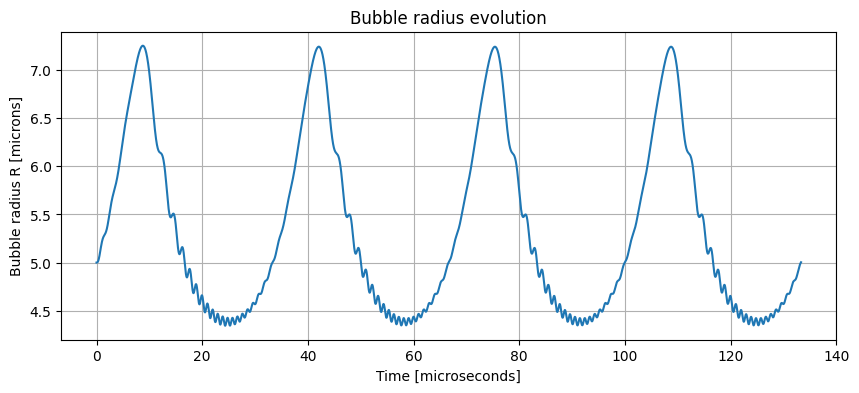

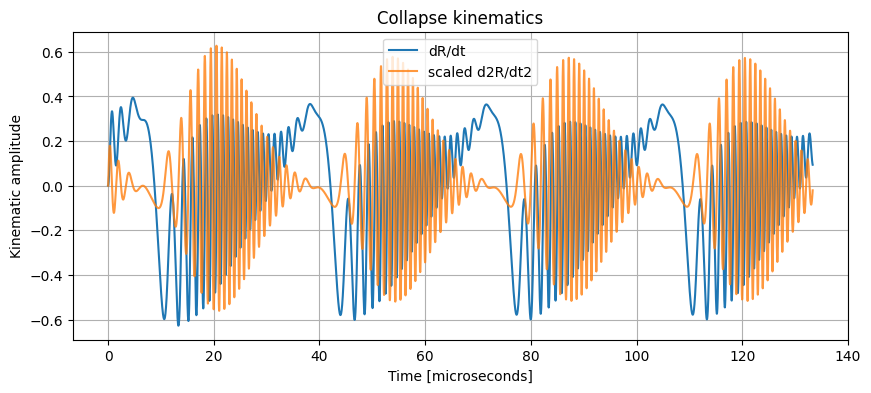

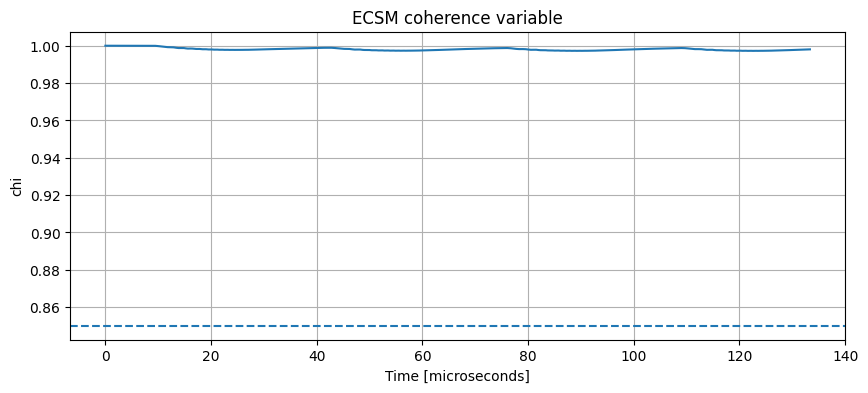

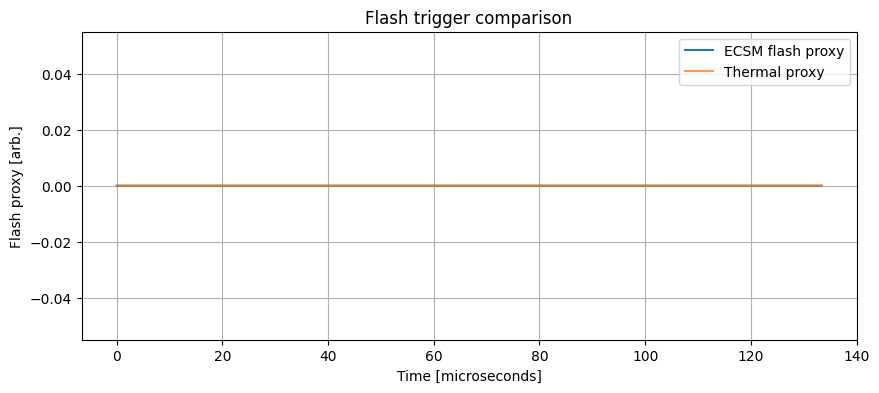

In [ ]:
# =========================
# CELL 6: PLOTS
# =========================

plt.figure(figsize=(10, 4))
plt.plot(t * 1e6, R * 1e6)
plt.xlabel("Time [microseconds]")
plt.ylabel("Bubble radius R [microns]")
plt.title("Bubble radius evolution")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t * 1e6, U, label="dR/dt")
plt.plot(t * 1e6, Rdd / np.max(np.abs(Rdd)) * np.max(np.abs(U)), label="scaled d2R/dt2", alpha=0.8)
plt.xlabel("Time [microseconds]")
plt.ylabel("Kinematic amplitude")
plt.title("Collapse kinematics")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t * 1e6, chi)
plt.axhline(params["chi_crit"], linestyle="--")
plt.xlabel("Time [microseconds]")
plt.ylabel("chi")
plt.title("ECSM coherence variable")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t * 1e6, P_flash_ecsm, label="ECSM flash proxy")
plt.plot(t * 1e6, P_flash_thermal, label="Thermal proxy", alpha=0.8)
plt.xlabel("Time [microseconds]")
plt.ylabel("Flash proxy [arb.]")
plt.title("Flash trigger comparison")
plt.legend()
plt.grid(True)
plt.show()

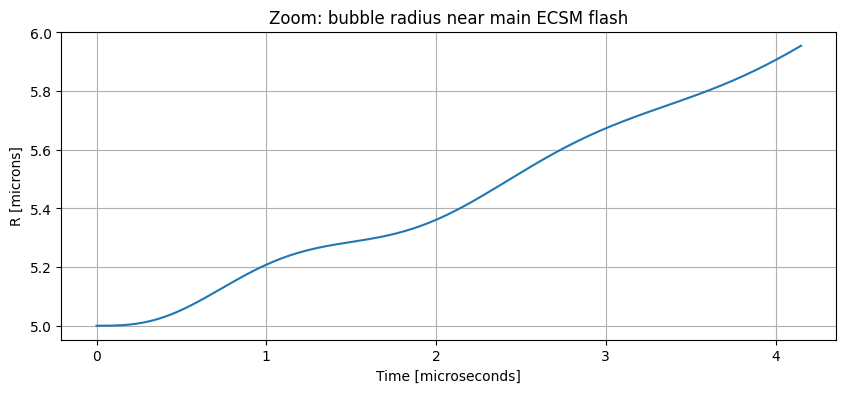

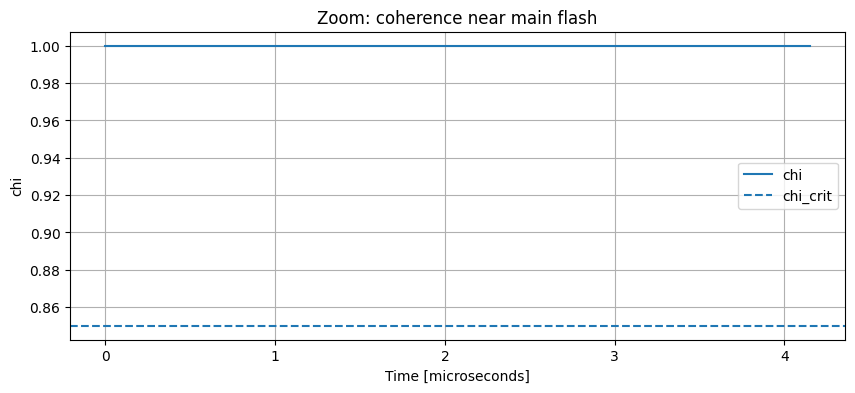

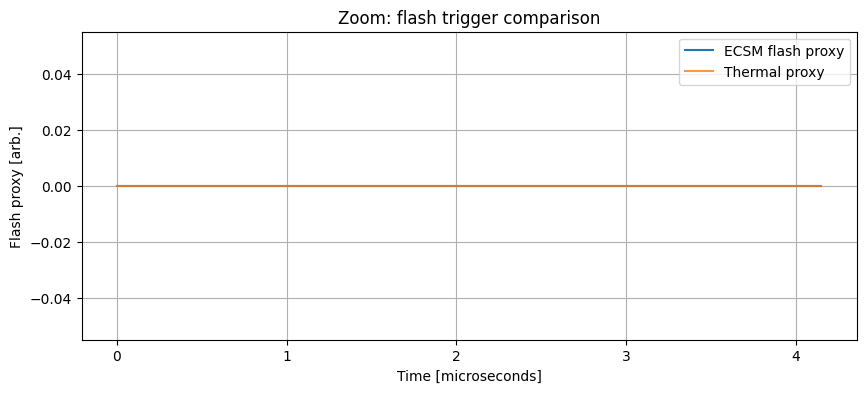

In [ ]:
# =========================
# CELL 7: ZOOM ON MAIN COLLAPSE
# =========================

i_peak = np.argmax(P_flash_ecsm)

window = 250
i0 = max(0, i_peak - window)
i1 = min(len(t), i_peak + window)

tz = t[i0:i1] * 1e6
Rz = R[i0:i1] * 1e6
chiz = chi[i0:i1]
Pez = P_flash_ecsm[i0:i1]
Pthz = P_flash_thermal[i0:i1]

plt.figure(figsize=(10, 4))
plt.plot(tz, Rz)
plt.xlabel("Time [microseconds]")
plt.ylabel("R [microns]")
plt.title("Zoom: bubble radius near main ECSM flash")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(tz, chiz, label="chi")
plt.axhline(params["chi_crit"], linestyle="--", label="chi_crit")
plt.xlabel("Time [microseconds]")
plt.ylabel("chi")
plt.title("Zoom: coherence near main flash")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(tz, Pez, label="ECSM flash proxy")
plt.plot(tz, Pthz, label="Thermal proxy", alpha=0.8)
plt.xlabel("Time [microseconds]")
plt.ylabel("Flash proxy [arb.]")
plt.title("Zoom: flash trigger comparison")
plt.legend()
plt.grid(True)
plt.show()

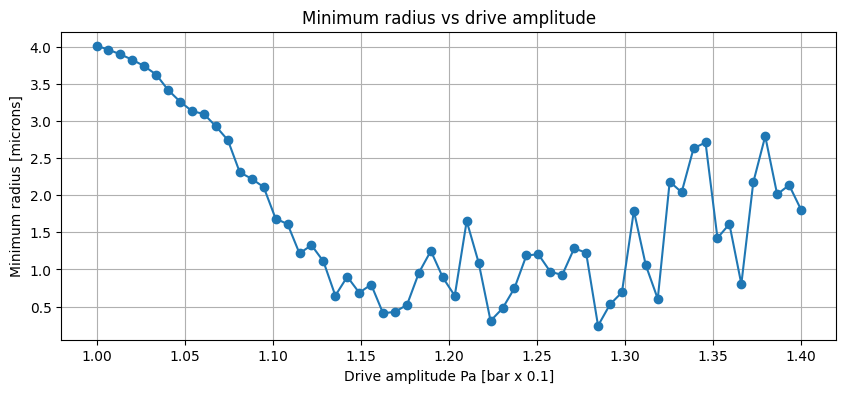

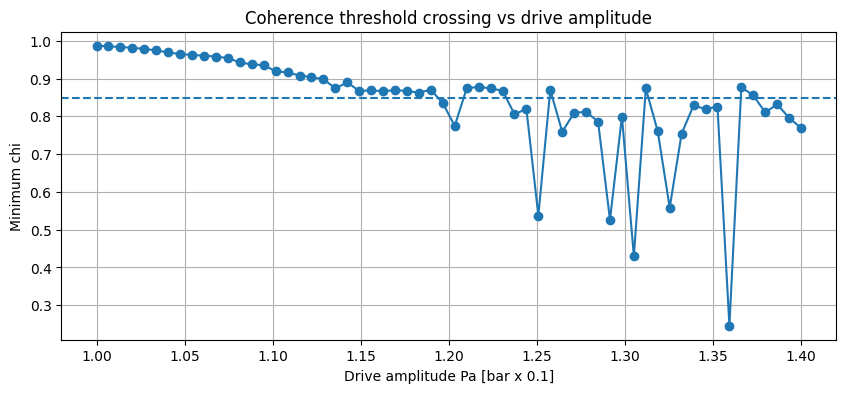

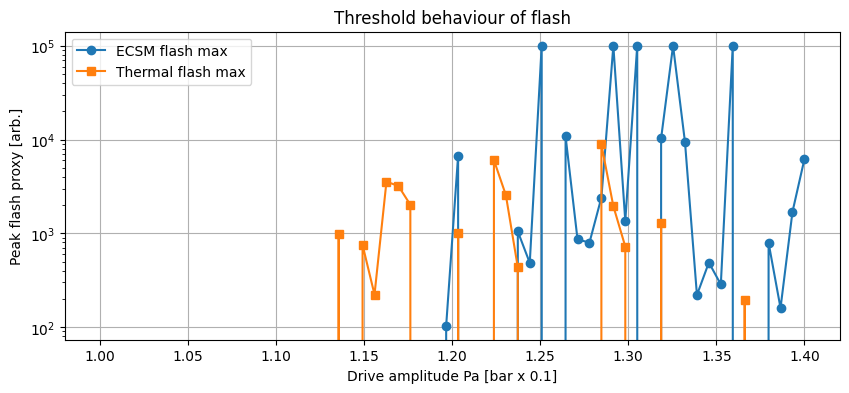

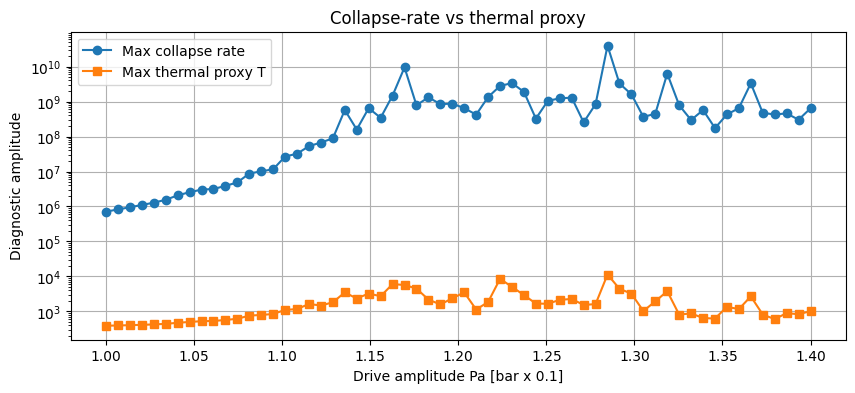

In [ ]:
# =========================
# CELL 8: SCAN DRIVE AMPLITUDE (SMOOTHED FLASH VERSION)
# =========================

def run_model_with_drive(Pa_value, base_params):
    p = dict(base_params)
    p["Pa"] = Pa_value

    sol = solve_ivp(
        fun=lambda t, y: bubble_rhs(t, y, p),
        t_span=(0.0, 4 / p["f"]),
        y0=[p["R0"], 0.0, p["chi0"]],
        t_eval=np.linspace(0.0, 4 / p["f"], 8000),
        method="Radau",
        rtol=1e-6,
        atol=1e-9,
    )

    t_loc = sol.t
    R_loc = sol.y[0]
    U_loc = sol.y[1]
    chi_loc = sol.y[2]

    Rdd_loc = compute_Rdd_series(t_loc, R_loc, U_loc, p)

    collapse_rate_loc = np.abs(U_loc / np.maximum(R_loc, 1.0e-12))

    dchi_dt_loc = np.gradient(chi_loc, t_loc)

    window = 9
    kernel = np.ones(window) / window
    dchi_dt_smooth_loc = np.convolve(dchi_dt_loc, kernel, mode="same")

    chi_deficit_loc = np.maximum(p["chi_crit"] - chi_loc, 0.0)
    P_ecsm = (
        p["A_flash"]
        * (chi_deficit_loc ** 2.0)
        * np.abs(dchi_dt_smooth_loc)
    )
    P_ecsm = np.clip(P_ecsm, 0.0, 1.0e5)

    T_proxy_loc = p["T0"] * (p["R0"] / np.maximum(R_loc, 1.0e-12)) ** (3.0 * (p["gamma_gas"] - 1.0))
    P_thermal = p["A_thermal"] * np.maximum(T_proxy_loc - p["Tcrit_proxy"], 0.0)

    return {
        "Pa": Pa_value,
        "Rmin": R_loc.min(),
        "chimin": chi_loc.min(),
        "flash_ecsm_max": P_ecsm.max(),
        "flash_thermal_max": P_thermal.max(),
        "collapse_rate_max": collapse_rate_loc.max(),
        "Tmax": T_proxy_loc.max(),
    }

Pa_vals = np.linspace(1.0e5, 1.4e5, 60)
scan = [run_model_with_drive(Pa, params) for Pa in Pa_vals]

Pa_plot = np.array([d["Pa"] for d in scan]) / 1e5
Rmin_plot = np.array([d["Rmin"] for d in scan]) * 1e6
chimin_plot = np.array([d["chimin"] for d in scan])
Fecsm_plot = np.array([d["flash_ecsm_max"] for d in scan])
Ftherm_plot = np.array([d["flash_thermal_max"] for d in scan])
Crate_plot = np.array([d["collapse_rate_max"] for d in scan])
Tmax_plot = np.array([d["Tmax"] for d in scan])

plt.figure(figsize=(10, 4))
plt.plot(Pa_plot, Rmin_plot, marker="o")
plt.xlabel("Drive amplitude Pa [bar x 0.1]")
plt.ylabel("Minimum radius [microns]")
plt.title("Minimum radius vs drive amplitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(Pa_plot, chimin_plot, marker="o")
plt.axhline(params["chi_crit"], linestyle="--")
plt.xlabel("Drive amplitude Pa [bar x 0.1]")
plt.ylabel("Minimum chi")
plt.title("Coherence threshold crossing vs drive amplitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(Pa_plot, Fecsm_plot, marker="o", label="ECSM flash max")
plt.plot(Pa_plot, Ftherm_plot, marker="s", label="Thermal flash max")
plt.yscale("log")
plt.xlabel("Drive amplitude Pa [bar x 0.1]")
plt.ylabel("Peak flash proxy [arb.]")
plt.title("Threshold behaviour of flash")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(Pa_plot, Crate_plot, marker="o", label="Max collapse rate")
plt.plot(Pa_plot, Tmax_plot, marker="s", label="Max thermal proxy T")
plt.yscale("log")
plt.xlabel("Drive amplitude Pa [bar x 0.1]")
plt.ylabel("Diagnostic amplitude")
plt.title("Collapse-rate vs thermal proxy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================
# CELL 9: THREE-REGIME COMPARISON
# =========================

def run_case_for_pa(Pa_value, base_params):
    p = dict(base_params)
    p["Pa"] = Pa_value

    sol = solve_ivp(
        fun=lambda t, y: bubble_rhs(t, y, p),
        t_span=(0.0, 4 / p["f"]),
        y0=[p["R0"], 0.0, p["chi0"]],
        t_eval=np.linspace(0.0, 4 / p["f"], 8000),
        method="Radau",
        rtol=1e-6,
        atol=1e-9,
    )

    t_loc = sol.t
    R_loc = sol.y[0]
    U_loc = sol.y[1]
    chi_loc = sol.y[2]

    # diagnostics
    collapse_rate_loc = np.abs(U_loc / np.maximum(R_loc, 1.0e-12))
    dchi_dt_loc = np.gradient(chi_loc, t_loc)

    window = 9
    kernel = np.ones(window) / window
    dchi_dt_smooth_loc = np.convolve(dchi_dt_loc, kernel, mode="same")

    chi_deficit_loc = np.maximum(p["chi_crit"] - chi_loc, 0.0)
    P_ecsm_loc = (
        p["A_flash"]
        * (chi_deficit_loc ** 2.0)
        * np.abs(dchi_dt_smooth_loc)
    )
    P_ecsm_loc = np.clip(P_ecsm_loc, 0.0, 1.0e5)

    T_proxy_loc = p["T0"] * (p["R0"] / np.maximum(R_loc, 1.0e-12)) ** (3.0 * (p["gamma_gas"] - 1.0))
    P_thermal_loc = p["A_thermal"] * np.maximum(T_proxy_loc - p["Tcrit_proxy"], 0.0)

    return {
        "Pa": Pa_value,
        "t": t_loc,
        "R": R_loc,
        "U": U_loc,
        "chi": chi_loc,
        "collapse_rate": collapse_rate_loc,
        "P_ecsm": P_ecsm_loc,
        "P_thermal": P_thermal_loc,
        "T_proxy": T_proxy_loc,
        "Rmin": R_loc.min(),
        "chimin": chi_loc.min(),
        "flashmax": P_ecsm_loc.max(),
        "Tmax": T_proxy_loc.max(),
        "crate_max": collapse_rate_loc.max(),
    }

# Choose three representative amplitudes from the scan
Pa_cases = [
    1.10e5,  # below threshold
    1.18e5,  # near threshold
    1.30e5,  # above threshold
]

case_results = [run_case_for_pa(Pa, params) for Pa in Pa_cases]

for case in case_results:
    print("=" * 60)
    print(f"Pa = {case['Pa']/1e5:.3f} x 1e5 Pa")
    print(f"Rmin = {case['Rmin']*1e6:.4f} microns")
    print(f"chi_min = {case['chimin']:.6f}")
    print(f"ECSM flash max = {case['flashmax']:.6e}")
    print(f"T_proxy max = {case['Tmax']:.6f}")
    print(f"collapse_rate max = {case['crate_max']:.6e}")

for case in case_results:
    t_us = case["t"] * 1e6
    R_um = case["R"] * 1e6
    chi_loc = case["chi"]
    crate = case["collapse_rate"]
    P_ecsm = case["P_ecsm"]
    P_thermal = case["P_thermal"]

    label = f"Pa = {case['Pa']/1e5:.3f} x 1e5 Pa"

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, R_um)
    plt.xlabel("Time [microseconds]")
    plt.ylabel("R [microns]")
    plt.title(f"Bubble radius: {label}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, chi_loc, label="chi")
    plt.axhline(params["chi_crit"], linestyle="--", label="chi_crit")
    plt.xlabel("Time [microseconds]")
    plt.ylabel("chi")
    plt.title(f"Coherence variable: {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, crate)
    plt.yscale("log")
    plt.xlabel("Time [microseconds]")
    plt.ylabel("Collapse rate |U/R|")
    plt.title(f"Collapse rate: {label}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, P_ecsm, label="ECSM flash proxy")
    plt.plot(t_us, P_thermal, label="Thermal proxy")
    plt.yscale("log")
    plt.xlabel("Time [microseconds]")
    plt.ylabel("Flash proxy [arb.]")
    plt.title(f"Flash comparison: {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================
# CELL 10: SMOOTH-ACTIVATION FLASH LAW TEST
# =========================

def run_case_for_pa_smooth(Pa_value, base_params, width=0.02):
    p = dict(base_params)
    p["Pa"] = Pa_value

    sol = solve_ivp(
        fun=lambda t, y: bubble_rhs(t, y, p),
        t_span=(0.0, 4 / p["f"]),
        y0=[p["R0"], 0.0, p["chi0"]],
        t_eval=np.linspace(0.0, 4 / p["f"], 8000),
        method="Radau",
        rtol=1e-6,
        atol=1e-9,
    )

    t_loc = sol.t
    R_loc = sol.y[0]
    U_loc = sol.y[1]
    chi_loc = sol.y[2]

    collapse_rate_loc = np.abs(U_loc / np.maximum(R_loc, 1.0e-12))
    dchi_dt_loc = np.gradient(chi_loc, t_loc)

    window = 9
    kernel = np.ones(window) / window
    dchi_dt_smooth_loc = np.convolve(dchi_dt_loc, kernel, mode="same")

    # Smooth activation instead of hard threshold
    chi_activation = 1.0 / (1.0 + np.exp((chi_loc - p["chi_crit"]) / width))

    P_ecsm_smooth = (
        p["A_flash"]
        * chi_activation
        * np.abs(dchi_dt_smooth_loc)
    )
    P_ecsm_smooth = np.clip(P_ecsm_smooth, 0.0, 1.0e5)

    T_proxy_loc = p["T0"] * (p["R0"] / np.maximum(R_loc, 1.0e-12)) ** (3.0 * (p["gamma_gas"] - 1.0))
    P_thermal_loc = p["A_thermal"] * np.maximum(T_proxy_loc - p["Tcrit_proxy"], 0.0)

    return {
        "Pa": Pa_value,
        "t": t_loc,
        "R": R_loc,
        "U": U_loc,
        "chi": chi_loc,
        "chi_activation": chi_activation,
        "collapse_rate": collapse_rate_loc,
        "P_ecsm_smooth": P_ecsm_smooth,
        "P_thermal": P_thermal_loc,
        "T_proxy": T_proxy_loc,
        "Rmin": R_loc.min(),
        "chimin": chi_loc.min(),
        "flashmax": P_ecsm_smooth.max(),
        "Tmax": T_proxy_loc.max(),
        "crate_max": collapse_rate_loc.max(),
    }

Pa_cases = [
    1.10e5,  # below threshold
    1.18e5,  # near threshold
    1.30e5,  # above threshold
]

smooth_results = [run_case_for_pa_smooth(Pa, params, width=0.02) for Pa in Pa_cases]

for case in smooth_results:
    print("=" * 60)
    print(f"Pa = {case['Pa']/1e5:.3f} x 1e5 Pa")
    print(f"Rmin = {case['Rmin']*1e6:.4f} microns")
    print(f"chi_min = {case['chimin']:.6f}")
    print(f"ECSM smooth flash max = {case['flashmax']:.6e}")
    print(f"T_proxy max = {case['Tmax']:.6f}")
    print(f"collapse_rate max = {case['crate_max']:.6e}")

for case in smooth_results:
    t_us = case["t"] * 1e6
    R_um = case["R"] * 1e6
    chi_loc = case["chi"]
    chi_act = case["chi_activation"]
    crate = case["collapse_rate"]
    P_ecsm = case["P_ecsm_smooth"]
    P_thermal = case["P_thermal"]

    label = f"Pa = {case['Pa']/1e5:.3f} x 1e5 Pa"

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, R_um)
    plt.xlabel("Time [microseconds]")
    plt.ylabel("R [microns]")
    plt.title(f"Bubble radius (smooth flash law): {label}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, chi_loc, label="chi")
    plt.axhline(params["chi_crit"], linestyle="--", label="chi_crit")
    plt.xlabel("Time [microseconds]")
    plt.ylabel("chi")
    plt.title(f"Coherence variable (smooth flash law): {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, chi_act, label="smooth activation")
    plt.xlabel("Time [microseconds]")
    plt.ylabel("Activation")
    plt.title(f"Smooth activation factor: {label}")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_us, crate)
    plt.yscale("log")
    plt.xlabel("Time [microseconds]")
    plt.ylabel("Collapse rate |U/R|")
    plt.title(f"Collapse rate (smooth flash law): {label}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    positive_ecsm = np.maximum(P_ecsm, 1e-12)
    positive_thermal = np.maximum(P_thermal, 1e-12)
    plt.plot(t_us, positive_ecsm, label="ECSM smooth flash proxy")
    plt.plot(t_us, positive_thermal, label="Thermal proxy")
    plt.yscale("log")
    plt.xlabel("Time [microseconds]")
    plt.ylabel("Flash proxy [arb.]")
    plt.title(f"Flash comparison (smooth law): {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================
# CELL 11: KILLER DIAGNOSTIC PLOT
# =========================

def run_case_for_pa_killer(Pa_value, base_params, width=0.02):
    p = dict(base_params)
    p["Pa"] = Pa_value

    sol = solve_ivp(
        fun=lambda t, y: bubble_rhs(t, y, p),
        t_span=(0.0, 4 / p["f"]),
        y0=[p["R0"], 0.0, p["chi0"]],
        t_eval=np.linspace(0.0, 4 / p["f"], 8000),
        method="Radau",
        rtol=1e-6,
        atol=1e-9,
    )

    t_loc = sol.t
    R_loc = sol.y[0]
    U_loc = sol.y[1]
    chi_loc = sol.y[2]

    collapse_rate_loc = np.abs(U_loc / np.maximum(R_loc, 1.0e-12))

    dchi_dt_loc = np.gradient(chi_loc, t_loc)
    window = 9
    kernel = np.ones(window) / window
    dchi_dt_smooth_loc = np.convolve(dchi_dt_loc, kernel, mode="same")

    chi_activation = 1.0 / (1.0 + np.exp((chi_loc - p["chi_crit"]) / width))

    P_ecsm_smooth = (
        p["A_flash"]
        * chi_activation
        * np.abs(dchi_dt_smooth_loc)
    )
    P_ecsm_smooth = np.clip(P_ecsm_smooth, 0.0, 1.0e5)

    T_proxy_loc = p["T0"] * (p["R0"] / np.maximum(R_loc, 1.0e-12)) ** (3.0 * (p["gamma_gas"] - 1.0))
    P_thermal_loc = p["A_thermal"] * np.maximum(T_proxy_loc - p["Tcrit_proxy"], 0.0)

    return {
        "Pa": Pa_value,
        "t": t_loc,
        "R": R_loc,
        "U": U_loc,
        "chi": chi_loc,
        "chi_activation": chi_activation,
        "collapse_rate": collapse_rate_loc,
        "P_ecsm_smooth": P_ecsm_smooth,
        "P_thermal": P_thermal_loc,
        "T_proxy": T_proxy_loc,
    }

# Choose the case you want to showcase
Pa_focus = 1.30e5

case = run_case_for_pa_killer(Pa_focus, params, width=0.02)

t_us = case["t"] * 1e6
R_um = case["R"] * 1e6
chi = case["chi"]
chi_act = case["chi_activation"]
collapse_rate = case["collapse_rate"]
P_ecsm = case["P_ecsm_smooth"]
T_proxy = case["T_proxy"]

# Key event times
i_Rmin = np.argmin(case["R"])
i_chimin = np.argmin(chi)
i_flash = np.argmax(P_ecsm)
i_Tmax = np.argmax(T_proxy)

print(f"Pa = {Pa_focus/1e5:.3f} x 1e5 Pa")
print(f"R_min = {R_um[i_Rmin]:.4f} microns at t = {t_us[i_Rmin]:.4f} us")
print(f"chi_min = {chi[i_chimin]:.6f} at t = {t_us[i_chimin]:.4f} us")
print(f"ECSM flash max = {P_ecsm[i_flash]:.6e} at t = {t_us[i_flash]:.4f} us")
print(f"T_proxy max = {T_proxy[i_Tmax]:.6f} at t = {t_us[i_Tmax]:.4f} us")

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

# 1. Bubble radius
axes[0].plot(t_us, R_um)
axes[0].axvline(t_us[i_Rmin], linestyle="--", label="R_min")
axes[0].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[0].set_ylabel("R [microns]")
axes[0].set_title(f"ECSM sonoluminescence diagnostic: Pa = {Pa_focus/1e5:.3f} x 1e5 Pa")
axes[0].legend()
axes[0].grid(True)

# 2. Chi
axes[1].plot(t_us, chi, label="chi")
axes[1].plot(t_us, chi_act, label="activation", alpha=0.8)
axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
axes[1].axvline(t_us[i_chimin], linestyle="--")
axes[1].axvline(t_us[i_flash], linestyle=":")
axes[1].set_ylabel("chi / act.")
axes[1].legend()
axes[1].grid(True)

# 3. Collapse rate
axes[2].plot(t_us, np.maximum(collapse_rate, 1e-12))
axes[2].axvline(t_us[i_Rmin], linestyle="--")
axes[2].axvline(t_us[i_flash], linestyle=":")
axes[2].set_yscale("log")
axes[2].set_ylabel("|U/R|")
axes[2].grid(True)

# 4. Flash proxy
axes[3].plot(t_us, np.maximum(P_ecsm, 1e-12), label="ECSM flash")
axes[3].plot(t_us, np.maximum(case["P_thermal"], 1e-12), label="Thermal proxy", alpha=0.8)
axes[3].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[3].axvline(t_us[i_Tmax], linestyle="--", label="T max")
axes[3].set_yscale("log")
axes[3].set_ylabel("Flash proxy")
axes[3].legend()
axes[3].grid(True)

# 5. Temperature proxy
axes[4].plot(t_us, T_proxy)
axes[4].axvline(t_us[i_Tmax], linestyle="--", label="T max")
axes[4].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[4].set_ylabel("T proxy")
axes[4].set_xlabel("Time [microseconds]")
axes[4].legend()
axes[4].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# CELL 12: LOCAL EVENT ALIGNMENT ANALYSIS
# =========================

def find_local_minima(arr):
    idx = []
    for i in range(1, len(arr) - 1):
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:
            idx.append(i)
    return np.array(idx, dtype=int)

# Reuse the same focus case from Cell 11
Pa_focus = 1.30e5
case = run_case_for_pa_killer(Pa_focus, params, width=0.02)

t_us = case["t"] * 1e6
R_um = case["R"] * 1e6
chi = case["chi"]
P_ecsm = case["P_ecsm_smooth"]
T_proxy = case["T_proxy"]

# Find all local minima in R(t)
candidate_mins = find_local_minima(case["R"])

# Filter out shallow / noisy minima:
# keep minima with relatively small radius
R_threshold = np.percentile(R_um[candidate_mins], 40) if len(candidate_mins) > 0 else np.inf
collapse_indices = [i for i in candidate_mins if R_um[i] <= R_threshold]

# Also enforce some minimum spacing so we don't double-count tiny oscillations
filtered = []
min_spacing = 120  # in index units; tweak if needed
for i in collapse_indices:
    if len(filtered) == 0 or (i - filtered[-1]) > min_spacing:
        filtered.append(i)

collapse_indices = np.array(filtered, dtype=int)

print(f"Detected collapse events: {len(collapse_indices)}")
print(f"Using Pa = {Pa_focus/1e5:.3f} x 1e5 Pa")
print()

event_rows = []

# Analyze a window around each collapse event
half_window = 120  # indices on each side

for n, i0 in enumerate(collapse_indices, start=1):
    a = max(0, i0 - half_window)
    b = min(len(t_us), i0 + half_window)

    # local event indices
    i_Rmin = a + np.argmin(R_um[a:b])
    i_Tmax = a + np.argmax(T_proxy[a:b])
    i_flash = a + np.argmax(P_ecsm[a:b])
    i_chimin = a + np.argmin(chi[a:b])

    row = {
        "event": n,
        "t_Rmin_us": t_us[i_Rmin],
        "Rmin_um": R_um[i_Rmin],
        "t_Tmax_us": t_us[i_Tmax],
        "Tmax": T_proxy[i_Tmax],
        "t_flash_us": t_us[i_flash],
        "flash_max": P_ecsm[i_flash],
        "t_chimin_us": t_us[i_chimin],
        "chi_min": chi[i_chimin],
        "flash_minus_Rmin_us": t_us[i_flash] - t_us[i_Rmin],
        "flash_minus_Tmax_us": t_us[i_flash] - t_us[i_Tmax],
        "flash_minus_chimin_us": t_us[i_flash] - t_us[i_chimin],
    }
    event_rows.append(row)

# Print summary table
for row in event_rows:
    print("=" * 72)
    print(f"Event {row['event']}")
    print(f"R_min      : t = {row['t_Rmin_us']:.4f} us   R = {row['Rmin_um']:.4f} um")
    print(f"T_max      : t = {row['t_Tmax_us']:.4f} us   T = {row['Tmax']:.4f}")
    print(f"Flash max  : t = {row['t_flash_us']:.4f} us   F = {row['flash_max']:.6e}")
    print(f"chi_min    : t = {row['t_chimin_us']:.4f} us   chi = {row['chi_min']:.6f}")
    print(f"Flash - Rmin   = {row['flash_minus_Rmin_us']:.4f} us")
    print(f"Flash - Tmax   = {row['flash_minus_Tmax_us']:.4f} us")
    print(f"Flash - chimin = {row['flash_minus_chimin_us']:.4f} us")

# Plot all detected events in one overview figure
plt.figure(figsize=(10, 5))
plt.plot(t_us, R_um, label="R(t)")
for j, i0 in enumerate(collapse_indices):
    plt.axvline(t_us[i0], linestyle="--", alpha=0.6, label="detected collapse" if j == 0 else None)
plt.xlabel("Time [microseconds]")
plt.ylabel("R [microns]")
plt.title(f"Detected collapse events: Pa = {Pa_focus/1e5:.3f} x 1e5 Pa")
plt.legend()
plt.grid(True)
plt.show()

# Plot each event window separately
for row, i0 in zip(event_rows, collapse_indices):
    a = max(0, i0 - half_window)
    b = min(len(t_us), i0 + half_window)

    i_Rmin = a + np.argmin(R_um[a:b])
    i_Tmax = a + np.argmax(T_proxy[a:b])
    i_flash = a + np.argmax(P_ecsm[a:b])
    i_chimin = a + np.argmin(chi[a:b])

    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    axes[0].plot(t_us[a:b], R_um[a:b])
    axes[0].axvline(t_us[i_Rmin], linestyle="--", label="R_min")
    axes[0].axvline(t_us[i_flash], linestyle=":", label="Flash max")
    axes[0].set_ylabel("R [um]")
    axes[0].set_title(f"Local event {row['event']}")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_us[a:b], chi[a:b], label="chi")
    axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
    axes[1].axvline(t_us[i_chimin], linestyle="--", label="chi_min")
    axes[1].axvline(t_us[i_flash], linestyle=":", label="Flash max")
    axes[1].set_ylabel("chi")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(t_us[a:b], np.maximum(P_ecsm[a:b], 1e-12), label="ECSM flash")
    axes[2].plot(t_us[a:b], np.maximum(T_proxy[a:b], 1e-12), label="T proxy")
    axes[2].axvline(t_us[i_Tmax], linestyle="--", label="T_max")
    axes[2].axvline(t_us[i_flash], linestyle=":", label="Flash max")
    axes[2].set_yscale("log")
    axes[2].set_ylabel("Flash / T")
    axes[2].legend()
    axes[2].grid(True)

    # timing offsets visual
    offsets = [
        row["flash_minus_Rmin_us"],
        row["flash_minus_Tmax_us"],
        row["flash_minus_chimin_us"],
    ]
    labels = ["Flash-Rmin", "Flash-Tmax", "Flash-chimin"]
    axes[3].bar(labels, offsets)
    axes[3].axhline(0.0, linestyle="--")
    axes[3].set_ylabel("Delta t [us]")
    axes[3].grid(True)

    axes[3].set_xlabel("Time / timing offsets")
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================
# CELL 13: DEGENERACY-BREAK TESTS (A, B, C)
# =========================

def run_case_variant(Pa_value, base_params, width=0.02, overrides=None):
    p = dict(base_params)
    p["Pa"] = Pa_value
    if overrides is not None:
        p.update(overrides)

    sol = solve_ivp(
        fun=lambda t, y: bubble_rhs(t, y, p),
        t_span=(0.0, 4 / p["f"]),
        y0=[p["R0"], 0.0, p["chi0"]],
        t_eval=np.linspace(0.0, 4 / p["f"], 8000),
        method="Radau",
        rtol=1e-6,
        atol=1e-9,
    )

    t_loc = sol.t
    R_loc = sol.y[0]
    U_loc = sol.y[1]
    chi_loc = sol.y[2]

    collapse_rate_loc = np.abs(U_loc / np.maximum(R_loc, 1.0e-12))

    dchi_dt_loc = np.gradient(chi_loc, t_loc)
    window = 9
    kernel = np.ones(window) / window
    dchi_dt_smooth_loc = np.convolve(dchi_dt_loc, kernel, mode="same")

    chi_activation = 1.0 / (1.0 + np.exp((chi_loc - p["chi_crit"]) / width))

    P_ecsm = (
        p["A_flash"]
        * chi_activation
        * np.abs(dchi_dt_smooth_loc)
    )
    P_ecsm = np.clip(P_ecsm, 0.0, 1.0e5)

    T_proxy = p["T0"] * (p["R0"] / np.maximum(R_loc, 1.0e-12)) ** (3.0 * (p["gamma_gas"] - 1.0))
    P_thermal = p["A_thermal"] * np.maximum(T_proxy - p["Tcrit_proxy"], 0.0)

    # global event indices
    i_Rmin = np.argmin(R_loc)
    i_Tmax = np.argmax(T_proxy)
    i_flash = np.argmax(P_ecsm)
    i_chimin = np.argmin(chi_loc)

    return {
        "params": p,
        "t": t_loc,
        "R": R_loc,
        "U": U_loc,
        "chi": chi_loc,
        "chi_activation": chi_activation,
        "collapse_rate": collapse_rate_loc,
        "P_ecsm": P_ecsm,
        "P_thermal": P_thermal,
        "T_proxy": T_proxy,
        "i_Rmin": i_Rmin,
        "i_Tmax": i_Tmax,
        "i_flash": i_flash,
        "i_chimin": i_chimin,
    }

Pa_focus = 1.30e5

variants = {
    "Baseline": {},
    "A_no_thermal": {
        "A_thermal": 0.0,
    },
    "B_low_gamma": {
        "gamma_gas": 1.10,
    },
    "C_high_chi_crit": {
        "chi_crit": 0.92,
    },
}

variant_results = {}

for name, overrides in variants.items():
    variant_results[name] = run_case_variant(
        Pa_value=Pa_focus,
        base_params=params,
        width=0.02,
        overrides=overrides
    )

# Print compact summary
print("=" * 88)
print(f"Degeneracy-break comparison at Pa = {Pa_focus/1e5:.3f} x 1e5 Pa")
print("=" * 88)

for name, case in variant_results.items():
    t_us = case["t"] * 1e6
    R_um = case["R"] * 1e6
    chi = case["chi"]
    P_ecsm = case["P_ecsm"]
    T_proxy = case["T_proxy"]

    i_Rmin = case["i_Rmin"]
    i_Tmax = case["i_Tmax"]
    i_flash = case["i_flash"]
    i_chimin = case["i_chimin"]

    print("-" * 88)
    print(name)
    print(f"R_min      = {R_um[i_Rmin]:.4f} um at t = {t_us[i_Rmin]:.4f} us")
    print(f"T_max      = {T_proxy[i_Tmax]:.4f} at t = {t_us[i_Tmax]:.4f} us")
    print(f"chi_min    = {chi[i_chimin]:.6f} at t = {t_us[i_chimin]:.4f} us")
    print(f"ECSM flash = {P_ecsm[i_flash]:.6e} at t = {t_us[i_flash]:.4f} us")
    print(f"Flash - Rmin   = {t_us[i_flash] - t_us[i_Rmin]:.4f} us")
    print(f"Flash - Tmax   = {t_us[i_flash] - t_us[i_Tmax]:.4f} us")
    print(f"Flash - chimin = {t_us[i_flash] - t_us[i_chimin]:.4f} us")

# Overview comparison plots
for name, case in variant_results.items():
    t_us = case["t"] * 1e6
    R_um = case["R"] * 1e6
    chi = case["chi"]
    chi_act = case["chi_activation"]
    collapse_rate = case["collapse_rate"]
    P_ecsm = case["P_ecsm"]
    P_thermal = case["P_thermal"]
    T_proxy = case["T_proxy"]

    i_Rmin = case["i_Rmin"]
    i_Tmax = case["i_Tmax"]
    i_flash = case["i_flash"]
    i_chimin = case["i_chimin"]

    fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

    axes[0].plot(t_us, R_um)
    axes[0].axvline(t_us[i_Rmin], linestyle="--", label="R_min")
    axes[0].axvline(t_us[i_flash], linestyle=":", label="Flash max")
    axes[0].set_ylabel("R [microns]")
    axes[0].set_title(name)
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_us, chi, label="chi")
    axes[1].plot(t_us, chi_act, label="activation", alpha=0.8)
    axes[1].axhline(case["params"]["chi_crit"], linestyle="--", label="chi_crit")
    axes[1].axvline(t_us[i_chimin], linestyle="--")
    axes[1].axvline(t_us[i_flash], linestyle=":")
    axes[1].set_ylabel("chi / act.")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(t_us, np.maximum(collapse_rate, 1e-12))
    axes[2].axvline(t_us[i_Rmin], linestyle="--")
    axes[2].axvline(t_us[i_flash], linestyle=":")
    axes[2].set_yscale("log")
    axes[2].set_ylabel("|U/R|")
    axes[2].grid(True)

    axes[3].plot(t_us, np.maximum(P_ecsm, 1e-12), label="ECSM flash")
    axes[3].plot(t_us, np.maximum(P_thermal, 1e-12), label="Thermal proxy", alpha=0.8)
    axes[3].axvline(t_us[i_flash], linestyle=":", label="Flash max")
    axes[3].axvline(t_us[i_Tmax], linestyle="--", label="T max")
    axes[3].set_yscale("log")
    axes[3].set_ylabel("Flash proxy")
    axes[3].legend()
    axes[3].grid(True)

    axes[4].plot(t_us, T_proxy)
    axes[4].axvline(t_us[i_Tmax], linestyle="--", label="T max")
    axes[4].axvline(t_us[i_flash], linestyle=":", label="Flash max")
    axes[4].set_ylabel("T proxy")
    axes[4].set_xlabel("Time [microseconds]")
    axes[4].legend()
    axes[4].grid(True)

    plt.tight_layout()
    plt.show()

Integration success: False
Solver message: Required step size is less than spacing between numbers.
Pa = 1.300 x 1e5 Pa
R_min = 2.6099 microns at t = 36.7713 us
chi_min = 0.928592 at t = 28.3202 us
chi_eq_min = 0.096430
ECSM flash max = 5.624279e+03 at t = 28.1535 us
T_proxy max = 654.537031 at t = 36.7713 us
Flash - Rmin   = -8.6177 us
Flash - Tmax   = -8.6177 us
Flash - chimin = -0.1667 us


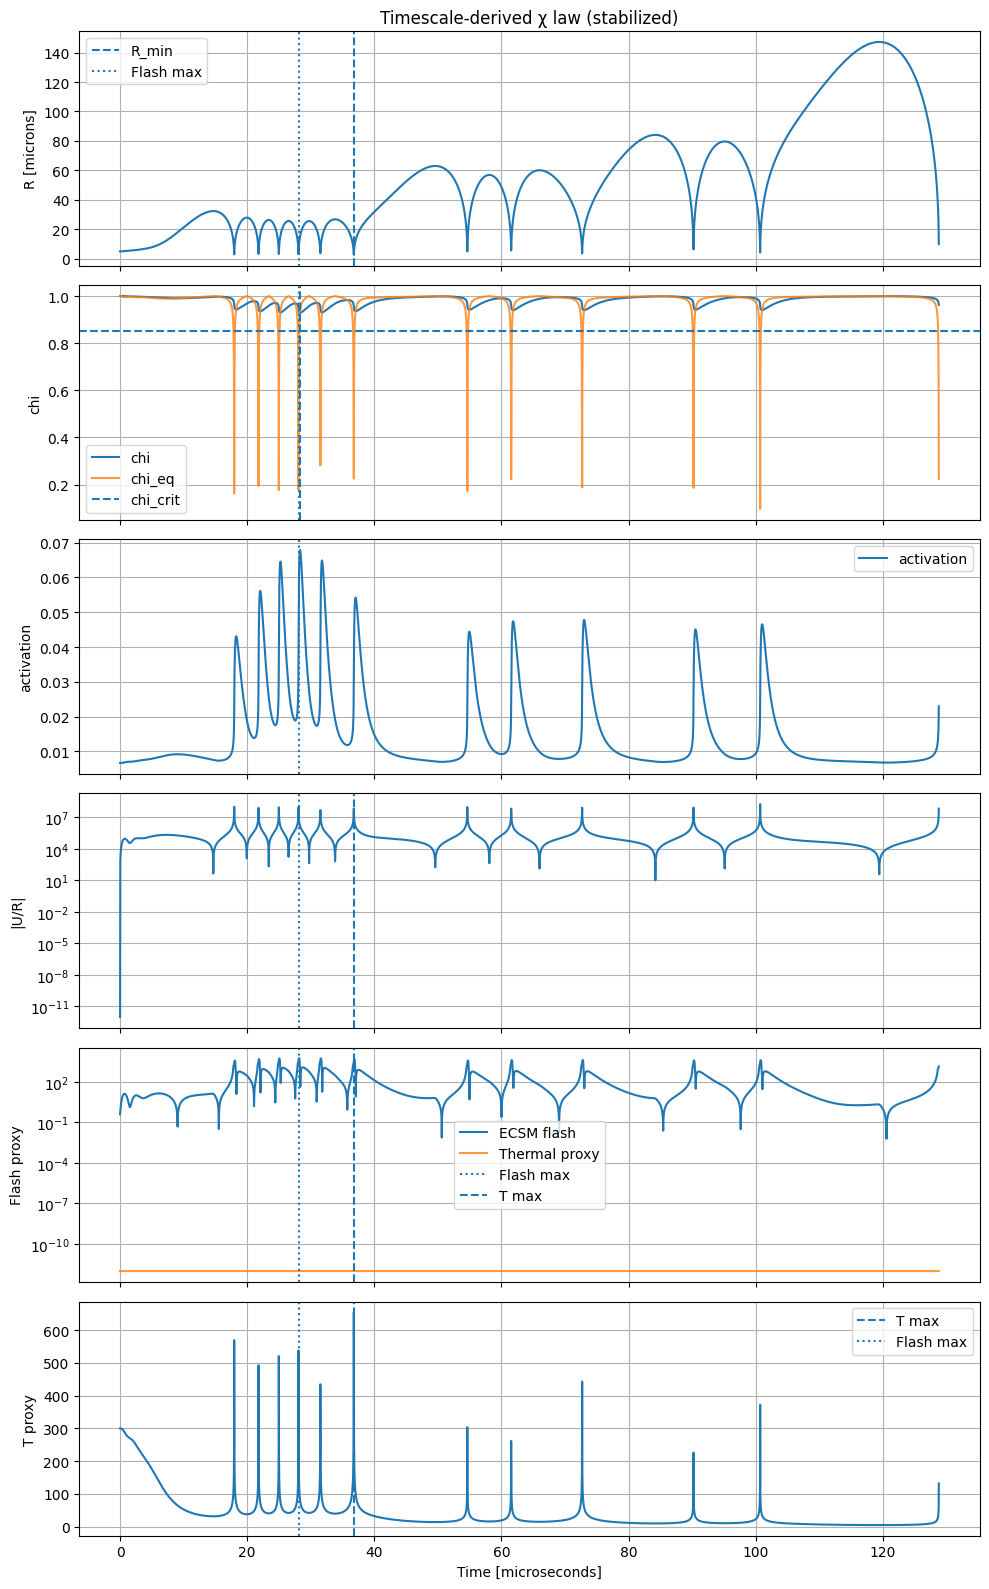

In [ ]:
# =========================
# CELL 14: TIMESCALE-DERIVED CHI LAW (STABILIZED)
# =========================

# --- softened timescale-based chi parameters ---
params_ts = dict(params)
params_ts.update({
    "tau_med": 5.0e-8,   # intrinsic medium response time [s]  (smaller = less violent chi_eq collapse)
    "tau_chi": 2.0e-6,   # relaxation time for chi to track chi_eq [s] (larger = smoother memory)
    "p_chi": 1.0,        # sharpness of coherence transition (smaller = less binary)
})

def bubble_rhs_timescale_chi(t, y, p):
    R, U, chi = y

    rho = p["rho"]
    mu = p["mu"]
    sigma = p["sigma"]

    R = max(R, 1.0e-9)

    Pin = gas_pressure(R, p)
    Pext = acoustic_pressure(t, p)

    rhs_pressure = (Pin - Pext - 2.0 * sigma / R - 4.0 * mu * U / R) / rho
    Rdd = (rhs_pressure - 1.5 * U**2) / R

    # forcing rate
    rate = np.abs(U) / max(R, 1.0e-12)

    # equilibrium coherence from timescale mismatch
    x = p["tau_med"] * rate
    chi_eq = 1.0 / (1.0 + x**p["p_chi"])

    # finite-memory relaxation toward chi_eq
    dchi_dt = (chi_eq - chi) / p["tau_chi"]

    # hard bounds
    if chi <= p["chi_floor"] and dchi_dt < 0:
        dchi_dt = 0.0
    if chi >= 1.0 and dchi_dt > 0:
        dchi_dt = 0.0

    return [U, Rdd, dchi_dt]

def run_case_timescale_chi(Pa_value, base_params, width=0.02):
    p = dict(base_params)
    p["Pa"] = Pa_value

    sol = solve_ivp(
        fun=lambda t, y: bubble_rhs_timescale_chi(t, y, p),
        t_span=(0.0, 4 / p["f"]),
        y0=[p["R0"], 0.0, p["chi0"]],
        t_eval=np.linspace(0.0, 4 / p["f"], 8000),
        method="Radau",
        rtol=1e-6,
        atol=1e-8,
    )

    t_loc = sol.t
    R_loc = sol.y[0]
    U_loc = sol.y[1]
    chi_loc = sol.y[2]

    collapse_rate_loc = np.abs(U_loc / np.maximum(R_loc, 1.0e-12))

    # explicit chi_eq history
    x = p["tau_med"] * collapse_rate_loc
    chi_eq_loc = 1.0 / (1.0 + x**p["p_chi"])

    dchi_dt_loc = np.gradient(chi_loc, t_loc)

    # slightly stronger smoothing
    window = 21
    kernel = np.ones(window) / window
    dchi_dt_smooth_loc = np.convolve(dchi_dt_loc, kernel, mode="same")

    # smooth activation
    chi_activation = 1.0 / (1.0 + np.exp((chi_loc - p["chi_crit"]) / width))

    P_ecsm = (
        p["A_flash"]
        * chi_activation
        * np.abs(dchi_dt_smooth_loc)
    )

    # softer clip ceiling to prevent one point dominating while still allowing structure
    P_ecsm = np.clip(P_ecsm, 0.0, 1.0e4)

    T_proxy = p["T0"] * (p["R0"] / np.maximum(R_loc, 1.0e-12)) ** (3.0 * (p["gamma_gas"] - 1.0))
    P_thermal = p["A_thermal"] * np.maximum(T_proxy - p["Tcrit_proxy"], 0.0)

    i_Rmin = np.argmin(R_loc)
    i_Tmax = np.argmax(T_proxy)
    i_flash = np.argmax(P_ecsm)
    i_chimin = np.argmin(chi_loc)

    return {
        "params": p,
        "t": t_loc,
        "R": R_loc,
        "U": U_loc,
        "chi": chi_loc,
        "chi_eq": chi_eq_loc,
        "chi_activation": chi_activation,
        "collapse_rate": collapse_rate_loc,
        "P_ecsm": P_ecsm,
        "P_thermal": P_thermal,
        "T_proxy": T_proxy,
        "i_Rmin": i_Rmin,
        "i_Tmax": i_Tmax,
        "i_flash": i_flash,
        "i_chimin": i_chimin,
        "success": sol.success,
        "message": sol.message,
    }

# choose the same focus point as before
Pa_focus = 1.30e5

case_ts = run_case_timescale_chi(Pa_focus, params_ts, width=0.03)

t_us = case_ts["t"] * 1e6
R_um = case_ts["R"] * 1e6
chi = case_ts["chi"]
chi_eq = case_ts["chi_eq"]
chi_act = case_ts["chi_activation"]
collapse_rate = case_ts["collapse_rate"]
P_ecsm = case_ts["P_ecsm"]
P_thermal = case_ts["P_thermal"]
T_proxy = case_ts["T_proxy"]

i_Rmin = case_ts["i_Rmin"]
i_Tmax = case_ts["i_Tmax"]
i_flash = case_ts["i_flash"]
i_chimin = case_ts["i_chimin"]

print("Integration success:", case_ts["success"])
print("Solver message:", case_ts["message"])
print(f"Pa = {Pa_focus/1e5:.3f} x 1e5 Pa")
print(f"R_min = {R_um[i_Rmin]:.4f} microns at t = {t_us[i_Rmin]:.4f} us")
print(f"chi_min = {chi[i_chimin]:.6f} at t = {t_us[i_chimin]:.4f} us")
print(f"chi_eq_min = {chi_eq.min():.6f}")
print(f"ECSM flash max = {P_ecsm[i_flash]:.6e} at t = {t_us[i_flash]:.4f} us")
print(f"T_proxy max = {T_proxy[i_Tmax]:.6f} at t = {t_us[i_Tmax]:.4f} us")
print(f"Flash - Rmin   = {t_us[i_flash] - t_us[i_Rmin]:.4f} us")
print(f"Flash - Tmax   = {t_us[i_flash] - t_us[i_Tmax]:.4f} us")
print(f"Flash - chimin = {t_us[i_flash] - t_us[i_chimin]:.4f} us")

fig, axes = plt.subplots(6, 1, figsize=(10, 16), sharex=True)

axes[0].plot(t_us, R_um)
axes[0].axvline(t_us[i_Rmin], linestyle="--", label="R_min")
axes[0].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[0].set_ylabel("R [microns]")
axes[0].set_title("Timescale-derived χ law (stabilized)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_us, chi, label="chi")
axes[1].plot(t_us, chi_eq, label="chi_eq", alpha=0.8)
axes[1].axhline(params_ts["chi_crit"], linestyle="--", label="chi_crit")
axes[1].axvline(t_us[i_chimin], linestyle="--")
axes[1].axvline(t_us[i_flash], linestyle=":")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t_us, chi_act, label="activation")
axes[2].axvline(t_us[i_flash], linestyle=":")
axes[2].set_ylabel("activation")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(t_us, np.maximum(collapse_rate, 1e-12))
axes[3].axvline(t_us[i_Rmin], linestyle="--")
axes[3].axvline(t_us[i_flash], linestyle=":")
axes[3].set_yscale("log")
axes[3].set_ylabel("|U/R|")
axes[3].grid(True)

axes[4].plot(t_us, np.maximum(P_ecsm, 1e-12), label="ECSM flash")
axes[4].plot(t_us, np.maximum(P_thermal, 1e-12), label="Thermal proxy", alpha=0.8)
axes[4].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[4].axvline(t_us[i_Tmax], linestyle="--", label="T max")
axes[4].set_yscale("log")
axes[4].set_ylabel("Flash proxy")
axes[4].legend()
axes[4].grid(True)

axes[5].plot(t_us, T_proxy)
axes[5].axvline(t_us[i_Tmax], linestyle="--", label="T max")
axes[5].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[5].set_ylabel("T proxy")
axes[5].set_xlabel("Time [microseconds]")
axes[5].legend()
axes[5].grid(True)

plt.tight_layout()
plt.show()

Integration success: True
Solver message: The solver successfully reached the end of the integration interval.
Pa = 1.300 x 1e5 Pa
R_min = 1.5689 microns at t = 28.0737 us
chi_min = 0.928594 at t = 28.3237 us
chi_eq_min = 0.038926
ECSM flash max = 5.621158e+03 at t = 28.1570 us
T_proxy max = 1205.477929 at t = 28.0737 us
Flash - Rmin   = 0.0834 us
Flash - Tmax   = 0.0834 us
Flash - chimin = -0.1667 us


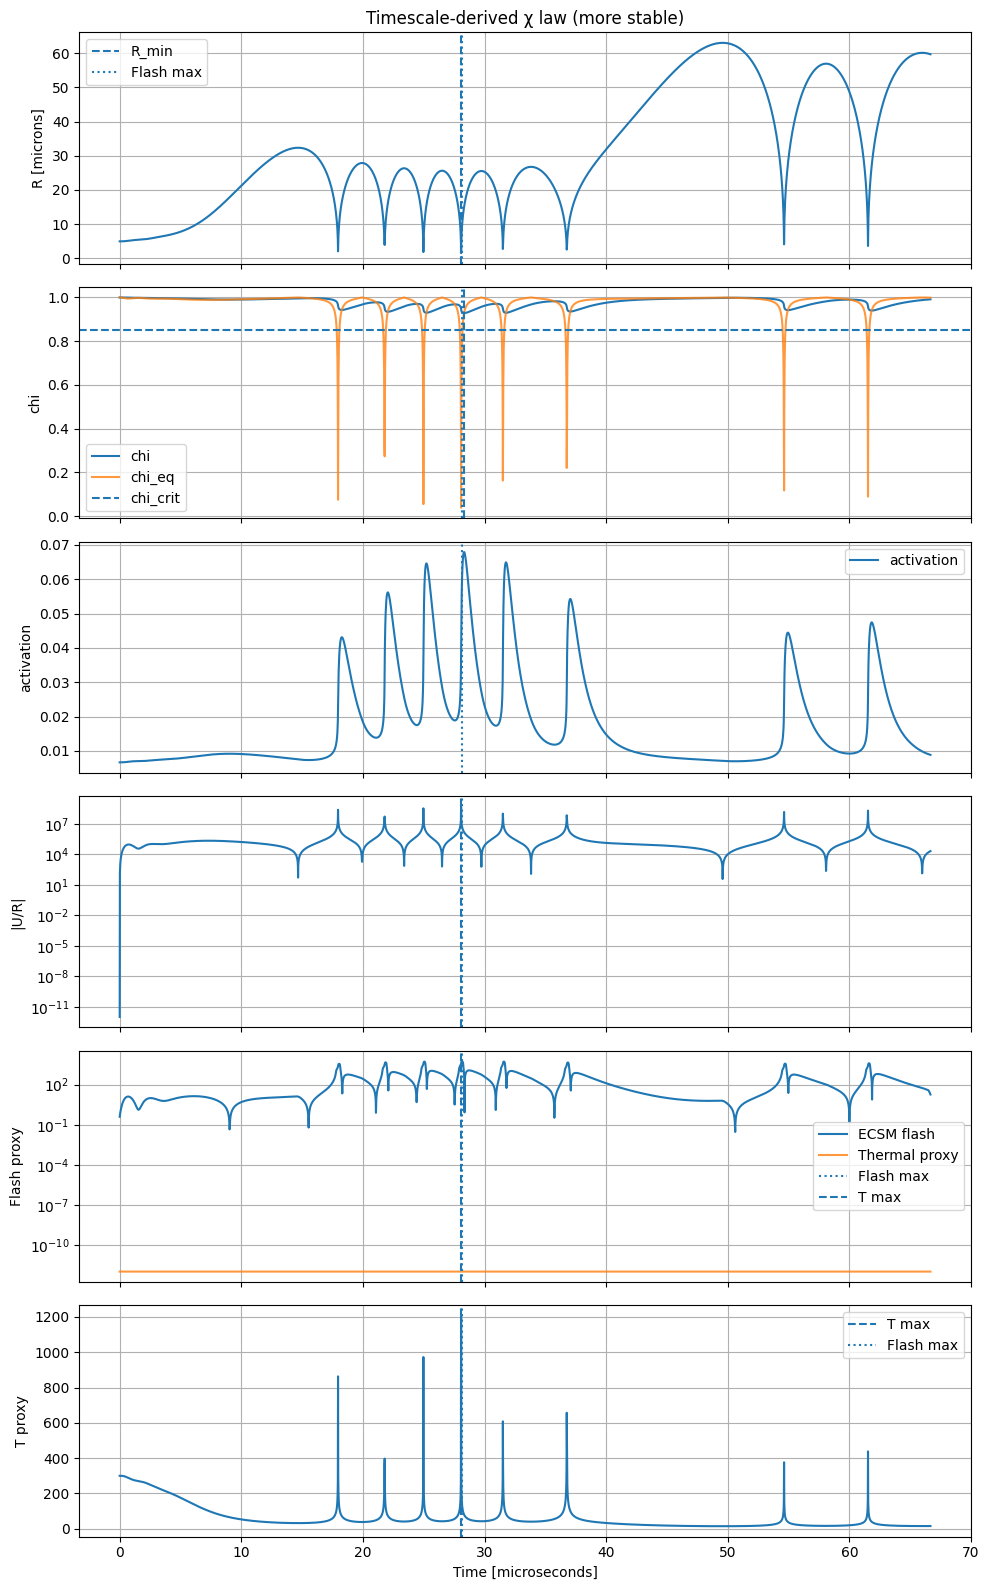

In [ ]:
# =========================
# CELL 14: TIMESCALE-DERIVED CHI LAW (MORE STABLE)
# =========================

params_ts = dict(params)
params_ts.update({
    "tau_med": 5.0e-8,
    "tau_chi": 2.0e-6,
    "p_chi": 1.0,
})

def bubble_rhs_timescale_chi(t, y, p):
    R, U, chi = y

    rho = p["rho"]
    mu = p["mu"]
    sigma = p["sigma"]

    R = max(R, 1.0e-9)

    Pin = gas_pressure(R, p)
    Pext = acoustic_pressure(t, p)

    rhs_pressure = (Pin - Pext - 2.0 * sigma / R - 4.0 * mu * U / R) / rho
    Rdd = (rhs_pressure - 1.5 * U**2) / R

    rate = np.abs(U) / max(R, 1.0e-12)
    x = p["tau_med"] * rate
    chi_eq = 1.0 / (1.0 + x**p["p_chi"])

    dchi_dt = (chi_eq - chi) / p["tau_chi"]

    if chi <= p["chi_floor"] and dchi_dt < 0:
        dchi_dt = 0.0
    if chi >= 1.0 and dchi_dt > 0:
        dchi_dt = 0.0

    return [U, Rdd, dchi_dt]

def run_case_timescale_chi(Pa_value, base_params, width=0.03):
    p = dict(base_params)
    p["Pa"] = Pa_value

    t_end = 2.0 / p["f"]
    t_eval = np.linspace(0.0, t_end, 4000)

    sol = solve_ivp(
        fun=lambda t, y: bubble_rhs_timescale_chi(t, y, p),
        t_span=(0.0, t_end),
        y0=[p["R0"], 0.0, p["chi0"]],
        t_eval=t_eval,
        method="Radau",
        rtol=1e-6,
        atol=1e-7,
    )

    t_loc = sol.t
    R_loc = sol.y[0]
    U_loc = sol.y[1]
    chi_loc = sol.y[2]

    collapse_rate_loc = np.abs(U_loc / np.maximum(R_loc, 1.0e-12))
    x = p["tau_med"] * collapse_rate_loc
    chi_eq_loc = 1.0 / (1.0 + x**p["p_chi"])

    dchi_dt_loc = np.gradient(chi_loc, t_loc)

    window = 21
    kernel = np.ones(window) / window
    dchi_dt_smooth_loc = np.convolve(dchi_dt_loc, kernel, mode="same")

    chi_activation = 1.0 / (1.0 + np.exp((chi_loc - p["chi_crit"]) / width))

    P_ecsm = (
        p["A_flash"]
        * chi_activation
        * np.abs(dchi_dt_smooth_loc)
    )
    P_ecsm = np.clip(P_ecsm, 0.0, 1.0e4)

    T_proxy = p["T0"] * (p["R0"] / np.maximum(R_loc, 1.0e-12)) ** (3.0 * (p["gamma_gas"] - 1.0))
    P_thermal = p["A_thermal"] * np.maximum(T_proxy - p["Tcrit_proxy"], 0.0)

    i_Rmin = np.argmin(R_loc)
    i_Tmax = np.argmax(T_proxy)
    i_flash = np.argmax(P_ecsm)
    i_chimin = np.argmin(chi_loc)

    return {
        "params": p,
        "t": t_loc,
        "R": R_loc,
        "U": U_loc,
        "chi": chi_loc,
        "chi_eq": chi_eq_loc,
        "chi_activation": chi_activation,
        "collapse_rate": collapse_rate_loc,
        "P_ecsm": P_ecsm,
        "P_thermal": P_thermal,
        "T_proxy": T_proxy,
        "i_Rmin": i_Rmin,
        "i_Tmax": i_Tmax,
        "i_flash": i_flash,
        "i_chimin": i_chimin,
        "success": sol.success,
        "message": sol.message,
    }

Pa_focus = 1.30e5

case_ts = run_case_timescale_chi(Pa_focus, params_ts, width=0.03)

t_us = case_ts["t"] * 1e6
R_um = case_ts["R"] * 1e6
chi = case_ts["chi"]
chi_eq = case_ts["chi_eq"]
chi_act = case_ts["chi_activation"]
collapse_rate = case_ts["collapse_rate"]
P_ecsm = case_ts["P_ecsm"]
P_thermal = case_ts["P_thermal"]
T_proxy = case_ts["T_proxy"]

i_Rmin = case_ts["i_Rmin"]
i_Tmax = case_ts["i_Tmax"]
i_flash = case_ts["i_flash"]
i_chimin = case_ts["i_chimin"]

print("Integration success:", case_ts["success"])
print("Solver message:", case_ts["message"])
print(f"Pa = {Pa_focus/1e5:.3f} x 1e5 Pa")
print(f"R_min = {R_um[i_Rmin]:.4f} microns at t = {t_us[i_Rmin]:.4f} us")
print(f"chi_min = {chi[i_chimin]:.6f} at t = {t_us[i_chimin]:.4f} us")
print(f"chi_eq_min = {chi_eq.min():.6f}")
print(f"ECSM flash max = {P_ecsm[i_flash]:.6e} at t = {t_us[i_flash]:.4f} us")
print(f"T_proxy max = {T_proxy[i_Tmax]:.6f} at t = {t_us[i_Tmax]:.4f} us")
print(f"Flash - Rmin   = {t_us[i_flash] - t_us[i_Rmin]:.4f} us")
print(f"Flash - Tmax   = {t_us[i_flash] - t_us[i_Tmax]:.4f} us")
print(f"Flash - chimin = {t_us[i_flash] - t_us[i_chimin]:.4f} us")

fig, axes = plt.subplots(6, 1, figsize=(10, 16), sharex=True)

axes[0].plot(t_us, R_um)
axes[0].axvline(t_us[i_Rmin], linestyle="--", label="R_min")
axes[0].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[0].set_ylabel("R [microns]")
axes[0].set_title("Timescale-derived χ law (more stable)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_us, chi, label="chi")
axes[1].plot(t_us, chi_eq, label="chi_eq", alpha=0.8)
axes[1].axhline(params_ts["chi_crit"], linestyle="--", label="chi_crit")
axes[1].axvline(t_us[i_chimin], linestyle="--")
axes[1].axvline(t_us[i_flash], linestyle=":")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t_us, chi_act, label="activation")
axes[2].axvline(t_us[i_flash], linestyle=":")
axes[2].set_ylabel("activation")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(t_us, np.maximum(collapse_rate, 1e-12))
axes[3].axvline(t_us[i_Rmin], linestyle="--")
axes[3].axvline(t_us[i_flash], linestyle=":")
axes[3].set_yscale("log")
axes[3].set_ylabel("|U/R|")
axes[3].grid(True)

axes[4].plot(t_us, np.maximum(P_ecsm, 1e-12), label="ECSM flash")
axes[4].plot(t_us, np.maximum(P_thermal, 1e-12), label="Thermal proxy", alpha=0.8)
axes[4].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[4].axvline(t_us[i_Tmax], linestyle="--", label="T max")
axes[4].set_yscale("log")
axes[4].set_ylabel("Flash proxy")
axes[4].legend()
axes[4].grid(True)

axes[5].plot(t_us, T_proxy)
axes[5].axvline(t_us[i_Tmax], linestyle="--", label="T max")
axes[5].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[5].set_ylabel("T proxy")
axes[5].set_xlabel("Time [microseconds]")
axes[5].legend()
axes[5].grid(True)

plt.tight_layout()
plt.show()

=== EMISSIVE RESERVOIR ===
Rmin time     = 28.0737 us
E_em max time = 28.0737 us
chi_min time  = 28.3237 us

E_em - Rmin   = 0.0000 us
E_em - chimin = -0.2501 us


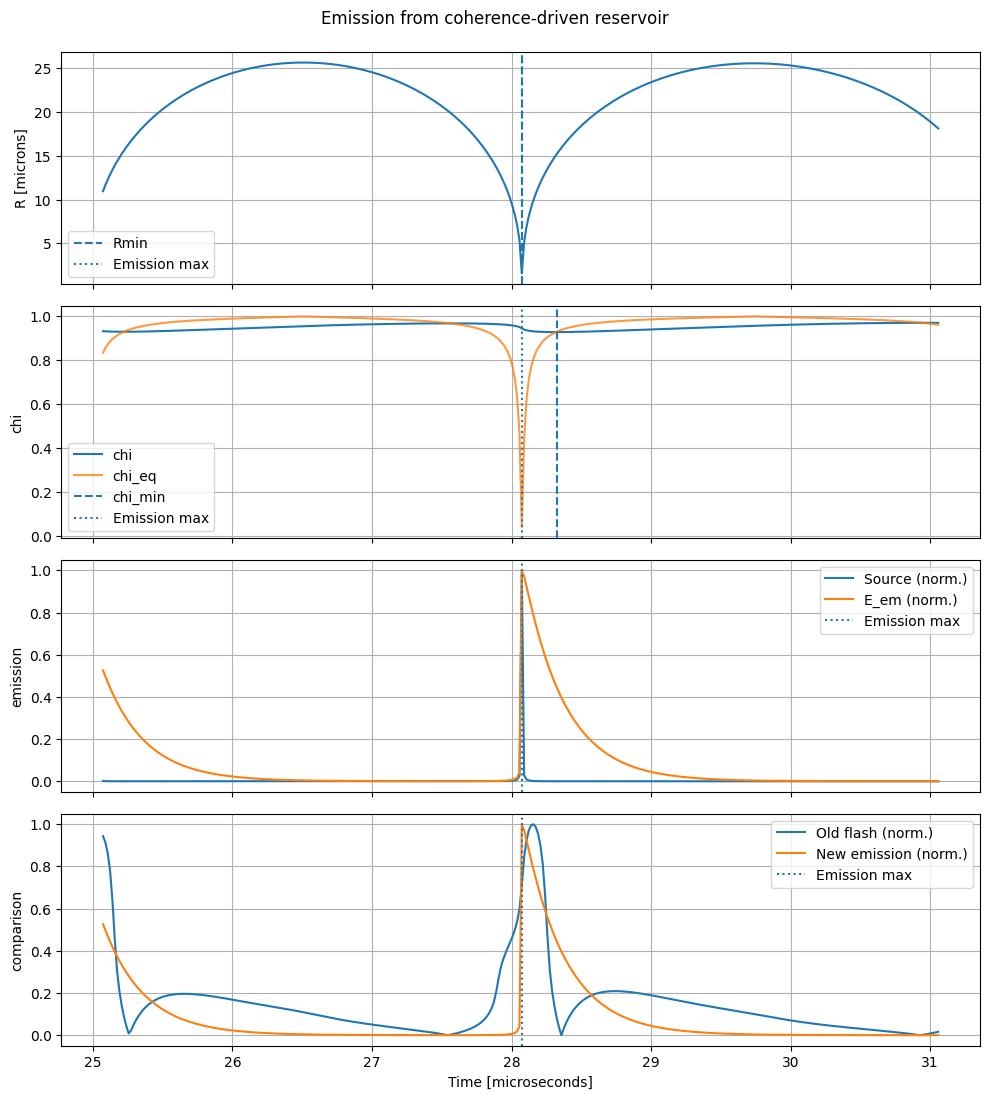

In [ ]:
# ============================================================
# CELL: EMISSIVE RESERVOIR MODEL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

t = case_ts["t"]
t_us = t * 1e6

R = case_ts["R"]
U = case_ts["U"]
chi = case_ts["chi"]
chi_eq = case_ts["chi_eq"]

collapse_rate = np.abs(U / np.maximum(R, 1e-12))

# -----------------------------
# parameters
# -----------------------------
A_em = 5e3
alpha = 1.0
beta = 1.0
tau_em = 3.0e-7   # <-- key knob (try 1e-7 to 1e-6)

# normalized collapse rate
crate_norm = collapse_rate / max(np.max(collapse_rate), 1e-30)

# source term
S_em = A_em * (crate_norm**alpha) * (np.abs(chi - chi_eq)**beta)

# evolve emissive reservoir
E_em = np.zeros_like(t)

for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    dE = (S_em[i] - E_em[i-1]) / tau_em
    E_em[i] = E_em[i-1] + dt * dE

# -----------------------------
# diagnostics
# -----------------------------
i_Rmin = np.argmin(R)
i_flash = np.argmax(E_em)
i_chimin = np.argmin(chi)

print("=== EMISSIVE RESERVOIR ===")
print(f"Rmin time     = {t_us[i_Rmin]:.4f} us")
print(f"E_em max time = {t_us[i_flash]:.4f} us")
print(f"chi_min time  = {t_us[i_chimin]:.4f} us")
print()
print(f"E_em - Rmin   = {t_us[i_flash] - t_us[i_Rmin]:.4f} us")
print(f"E_em - chimin = {t_us[i_flash] - t_us[i_chimin]:.4f} us")

# -----------------------------
# local plot
# -----------------------------
half_window = 180
a = max(0, i_Rmin - half_window)
b = min(len(t), i_Rmin + half_window)

tt = t_us[a:b]

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)

axes[0].plot(tt, R[a:b]*1e6)
axes[0].axvline(t_us[i_Rmin], linestyle="--", label="Rmin")
axes[0].axvline(t_us[i_flash], linestyle=":", label="Emission max")
axes[0].set_ylabel("R [microns]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(tt, chi[a:b], label="chi")
axes[1].plot(tt, chi_eq[a:b], label="chi_eq", alpha=0.8)
axes[1].axvline(t_us[i_chimin], linestyle="--", label="chi_min")
axes[1].axvline(t_us[i_flash], linestyle=":", label="Emission max")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(tt, S_em[a:b] / max(np.max(S_em[a:b]), 1e-30), label="Source (norm.)")
axes[2].plot(tt, E_em[a:b] / max(np.max(E_em[a:b]), 1e-30), label="E_em (norm.)")
axes[2].axvline(t_us[i_flash], linestyle=":", label="Emission max")
axes[2].set_ylabel("emission")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(tt, case_ts["P_ecsm"][a:b] / np.max(case_ts["P_ecsm"][a:b]), label="Old flash (norm.)")
axes[3].plot(tt, E_em[a:b] / max(np.max(E_em[a:b]), 1e-30), label="New emission (norm.)")
axes[3].axvline(t_us[i_flash], linestyle=":", label="Emission max")
axes[3].set_ylabel("comparison")
axes[3].set_xlabel("Time [microseconds]")
axes[3].legend()
axes[3].grid(True)

fig.suptitle("Emission from coherence-driven reservoir", y=0.995)
plt.tight_layout()
plt.show()


=== LOCAL EFFECTIVE TEMPERATURE TEST ===
Rmin time      = 28.0737 us
T_ad max       = 28.0737 us
T_eff_A max    = 28.0737 us
T_eff_B max    = 28.0737 us

Offsets relative to Rmin:
T_ad  - Rmin = 0.0000 us
T_A   - Rmin = 0.0000 us
T_B   - Rmin = 0.0000 us


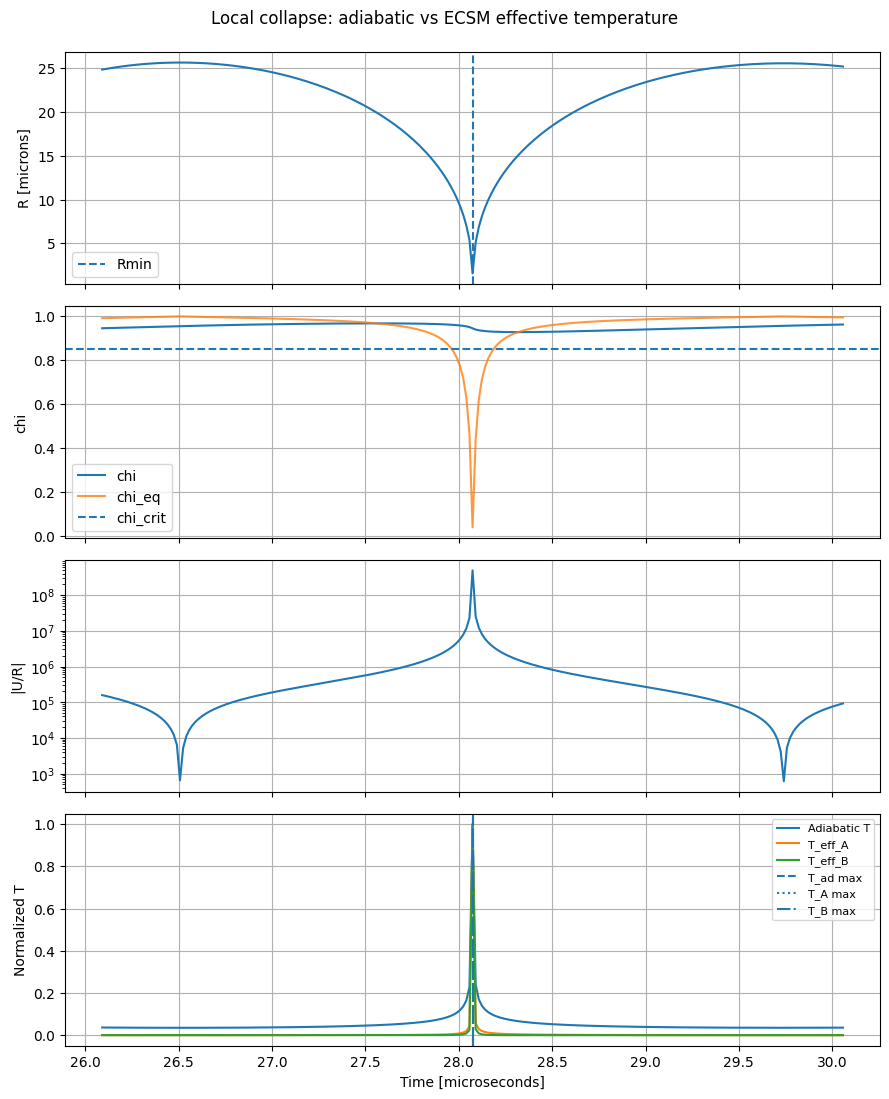

In [ ]:
# ============================================================
# CELL: LOCAL EFFECTIVE TEMPERATURE DIAGNOSTIC (CLEAN)
# Focus ONLY on main collapse event (paper-safe)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- get data from timescale run ---
t_us = case_ts["t"] * 1e6
R = case_ts["R"]
chi = case_ts["chi"]
chi_eq = case_ts["chi_eq"]
U = case_ts["U"]

# --- core quantities ---
collapse_rate = np.abs(U / np.maximum(R, 1e-12))

# adiabatic temperature proxy
T_ad = params_ts["T0"] * (params_ts["R0"] / np.maximum(R, 1e-12)) ** (3.0 * (params_ts["gamma_gas"] - 1.0))

# ECSM effective temperature laws
T_eff_A = collapse_rate * (1.0 - chi)
T_eff_B = collapse_rate * np.abs(chi - chi_eq)

# --- find main collapse ---
i_Rmin = np.argmin(R)
t0 = t_us[i_Rmin]

# --- define LOCAL WINDOW (very important) ---
window_us = 2.0   # +/- microseconds around collapse
mask = (t_us > t0 - window_us) & (t_us < t0 + window_us)

t_loc = t_us[mask]
R_loc = R[mask] * 1e6
chi_loc = chi[mask]
chi_eq_loc = chi_eq[mask]
crate_loc = collapse_rate[mask]

Tad_loc = T_ad[mask]
TA_loc = T_eff_A[mask]
TB_loc = T_eff_B[mask]

# --- local maxima ---
i_Rmin_loc = np.argmin(R_loc)
i_Tad_max = np.argmax(Tad_loc)
i_TA_max = np.argmax(TA_loc)
i_TB_max = np.argmax(TB_loc)

# --- print diagnostics ---
print("\n=== LOCAL EFFECTIVE TEMPERATURE TEST ===")
print(f"Rmin time      = {t_loc[i_Rmin_loc]:.4f} us")
print(f"T_ad max       = {t_loc[i_Tad_max]:.4f} us")
print(f"T_eff_A max    = {t_loc[i_TA_max]:.4f} us")
print(f"T_eff_B max    = {t_loc[i_TB_max]:.4f} us")

print("\nOffsets relative to Rmin:")
print(f"T_ad  - Rmin = {t_loc[i_Tad_max] - t_loc[i_Rmin_loc]:.4f} us")
print(f"T_A   - Rmin = {t_loc[i_TA_max] - t_loc[i_Rmin_loc]:.4f} us")
print(f"T_B   - Rmin = {t_loc[i_TB_max] - t_loc[i_Rmin_loc]:.4f} us")

# --- plotting ---
fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

# R
axes[0].plot(t_loc, R_loc)
axes[0].axvline(t_loc[i_Rmin_loc], linestyle="--", label="Rmin")
axes[0].set_ylabel("R [microns]")
axes[0].legend()
axes[0].grid(True)

# chi
axes[1].plot(t_loc, chi_loc, label="chi")
axes[1].plot(t_loc, chi_eq_loc, label="chi_eq", alpha=0.8)
axes[1].axhline(params_ts["chi_crit"], linestyle="--", label="chi_crit")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

# collapse rate
axes[2].plot(t_loc, np.maximum(crate_loc, 1e-12))
axes[2].set_yscale("log")
axes[2].set_ylabel("|U/R|")
axes[2].grid(True)

# temperature comparison (NORMALIZED for clarity)
def norm(x):
    return x / np.max(x)

axes[3].plot(t_loc, norm(Tad_loc), label="Adiabatic T")
axes[3].plot(t_loc, norm(TA_loc), label="T_eff_A")
axes[3].plot(t_loc, norm(TB_loc), label="T_eff_B")

axes[3].axvline(t_loc[i_Tad_max], linestyle="--", label="T_ad max")
axes[3].axvline(t_loc[i_TA_max], linestyle=":", label="T_A max")
axes[3].axvline(t_loc[i_TB_max], linestyle="-.", label="T_B max")

axes[3].set_ylabel("Normalized T")
axes[3].set_xlabel("Time [microseconds]")
axes[3].legend(fontsize=8)
axes[3].grid(True)

fig.suptitle("Local collapse: adiabatic vs ECSM effective temperature", y=0.995)
plt.tight_layout()
plt.savefig("fig_effective_temperature_local.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CELL: BUILD ALL PAPER FIGURES
# Assumes you already have:
# - params, params_ts
# - run_case_for_pa_smooth(...)
# - run_case_timescale_chi(...)
# - run_case_variant(...)
# - run_case_for_pa(...)   [used for scan]
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helpers
# -----------------------------
def _safe_positive(x, floor=1e-12):
    return np.maximum(np.asarray(x), floor)

def _savefig(name):
    plt.savefig(name, dpi=300, bbox_inches="tight")
    print(f"Saved {name}")

# -----------------------------
# Shared settings
# -----------------------------
Pa_focus = 1.30e5
width_smooth = 0.02
width_ts = 0.03

# -----------------------------
# FIGURE 1: chi vs chi_eq
# -----------------------------
case_ts = run_case_timescale_chi(Pa_focus, params_ts, width=width_ts)

t_us = case_ts["t"] * 1e6
chi = case_ts["chi"]
chi_eq = case_ts["chi_eq"]

plt.figure(figsize=(9, 4.8))
plt.plot(t_us, chi, label=r"$\chi$")
plt.plot(t_us, chi_eq, label=r"$\chi_{\mathrm{eq}}$", alpha=0.85)
plt.axhline(case_ts["params"]["chi_crit"], linestyle="--", label=r"$\chi_{\mathrm{crit}}$")
plt.xlabel("Time [microseconds]")
plt.ylabel("Coherence")
plt.title(r"Comparison of $\chi$ and $\chi_{\mathrm{eq}}$")
plt.legend()
plt.grid(True)
_savefig("fig1_chi_eq.png")
plt.show()

# -----------------------------
# FIGURE 2: main diagnostic
# timescale-derived stable case
# -----------------------------
R_um = case_ts["R"] * 1e6
chi_act = case_ts["chi_activation"]
collapse_rate = case_ts["collapse_rate"]
P_ecsm = case_ts["P_ecsm"]
P_thermal = case_ts["P_thermal"]
T_proxy = case_ts["T_proxy"]

i_Rmin = case_ts["i_Rmin"]
i_Tmax = case_ts["i_Tmax"]
i_flash = case_ts["i_flash"]
i_chimin = case_ts["i_chimin"]

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

axes[0].plot(t_us, R_um)
axes[0].axvline(t_us[i_Rmin], linestyle="--", label="Rmin")
axes[0].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[0].set_ylabel("R [microns]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_us, chi, label="chi")
axes[1].plot(t_us, chi_act, label="activation", alpha=0.85)
axes[1].axhline(case_ts["params"]["chi_crit"], linestyle="--", label="chi_crit")
axes[1].axvline(t_us[i_chimin], linestyle="--")
axes[1].axvline(t_us[i_flash], linestyle=":")
axes[1].set_ylabel("chi / act.")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t_us, _safe_positive(collapse_rate))
axes[2].axvline(t_us[i_Rmin], linestyle="--")
axes[2].axvline(t_us[i_flash], linestyle=":")
axes[2].set_yscale("log")
axes[2].set_ylabel("|U/R|")
axes[2].grid(True)

axes[3].plot(t_us, _safe_positive(P_ecsm), label="ECSM flash")
axes[3].plot(t_us, _safe_positive(P_thermal), label="Thermal proxy", alpha=0.85)
axes[3].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[3].axvline(t_us[i_Tmax], linestyle="--", label="Tmax")
axes[3].set_yscale("log")
axes[3].set_ylabel("Flash proxy")
axes[3].legend()
axes[3].grid(True)

axes[4].plot(t_us, T_proxy)
axes[4].axvline(t_us[i_Tmax], linestyle="--", label="Tmax")
axes[4].axvline(t_us[i_flash], linestyle=":", label="Flash max")
axes[4].set_ylabel("T proxy")
axes[4].set_xlabel("Time [microseconds]")
axes[4].legend()
axes[4].grid(True)

fig.suptitle("Time evolution of bubble dynamics, coherence, and emission", y=0.995)
plt.tight_layout()
_savefig("fig2_diagnostic.png")
plt.show()

# -----------------------------
# FIGURE 3: clean diagnostic
# smoother, simpler view
# -----------------------------
case_smooth = run_case_for_pa_smooth(Pa_focus, params, width=width_smooth)

t3_us = case_smooth["t"] * 1e6
R3_um = case_smooth["R"] * 1e6
chi3 = case_smooth["chi"]
crate3 = case_smooth["collapse_rate"]
P3 = case_smooth["P_ecsm_smooth"]
PT3 = case_smooth["P_thermal"]

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)

axes[0].plot(t3_us, R3_um)
axes[0].set_ylabel("R [microns]")
axes[0].grid(True)

axes[1].plot(t3_us, chi3, label="chi")
axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t3_us, _safe_positive(crate3))
axes[2].set_yscale("log")
axes[2].set_ylabel("|U/R|")
axes[2].grid(True)

axes[3].plot(t3_us, _safe_positive(P3), label="ECSM flash")
axes[3].plot(t3_us, _safe_positive(PT3), label="Thermal proxy", alpha=0.85)
axes[3].set_yscale("log")
axes[3].set_ylabel("Proxy")
axes[3].set_xlabel("Time [microseconds]")
axes[3].legend()
axes[3].grid(True)

fig.suptitle("Time-resolved diagnostics of driven bubble collapse", y=0.995)
plt.tight_layout()
_savefig("fig3_diagnostic.png")
plt.show()

# -----------------------------
# FIGURE 4: event zoom
# from local event alignment on smooth case
# -----------------------------
def find_local_minima(arr):
    idx = []
    for i in range(1, len(arr) - 1):
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:
            idx.append(i)
    return np.array(idx, dtype=int)

candidate_mins = find_local_minima(case_smooth["R"])
if len(candidate_mins) == 0:
    raise RuntimeError("No local minima found for event zoom figure.")

Rmin_vals = (case_smooth["R"][candidate_mins] * 1e6)
R_threshold = np.percentile(Rmin_vals, 40)
collapse_indices = [i for i in candidate_mins if (case_smooth["R"][i] * 1e6) <= R_threshold]

filtered = []
min_spacing = 120
for i in collapse_indices:
    if len(filtered) == 0 or (i - filtered[-1]) > min_spacing:
        filtered.append(i)

collapse_indices = np.array(filtered, dtype=int)
if len(collapse_indices) == 0:
    collapse_indices = np.array([candidate_mins[np.argmin(case_smooth["R"][candidate_mins])]])

# use first representative event
i0 = collapse_indices[min(0, len(collapse_indices)-1)]
half_window = 120
a = max(0, i0 - half_window)
b = min(len(t3_us), i0 + half_window)

i_Rmin_loc = a + np.argmin(R3_um[a:b])
i_Tmax_loc = a + np.argmax(case_smooth["T_proxy"][a:b])
i_flash_loc = a + np.argmax(P3[a:b])
i_chimin_loc = a + np.argmin(chi3[a:b])

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(t3_us[a:b], R3_um[a:b])
axes[0].axvline(t3_us[i_Rmin_loc], linestyle="--", label="Rmin")
axes[0].axvline(t3_us[i_flash_loc], linestyle=":", label="Flash max")
axes[0].set_ylabel("R [microns]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t3_us[a:b], chi3[a:b], label="chi")
axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
axes[1].axvline(t3_us[i_chimin_loc], linestyle="--", label="chi_min")
axes[1].axvline(t3_us[i_flash_loc], linestyle=":", label="Flash max")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t3_us[a:b], _safe_positive(P3[a:b]), label="ECSM flash")
axes[2].plot(t3_us[a:b], _safe_positive(case_smooth["P_thermal"][a:b]), label="Thermal proxy", alpha=0.85)
axes[2].axvline(t3_us[i_Tmax_loc], linestyle="--", label="Tmax")
axes[2].axvline(t3_us[i_flash_loc], linestyle=":", label="Flash max")
axes[2].set_yscale("log")
axes[2].set_ylabel("Proxy")
axes[2].legend()
axes[2].grid(True)

offsets = [
    t3_us[i_flash_loc] - t3_us[i_Rmin_loc],
    t3_us[i_flash_loc] - t3_us[i_Tmax_loc],
    t3_us[i_flash_loc] - t3_us[i_chimin_loc],
]
labels = ["Flash-Rmin", "Flash-Tmax", "Flash-chi_min"]
axes[3].bar(labels, offsets)
axes[3].axhline(0.0, linestyle="--")
axes[3].set_ylabel("Delta t [us]")
axes[3].grid(True)
axes[3].set_xlabel("Local event timing")

fig.suptitle("Zoomed collapse event structure", y=0.995)
plt.tight_layout()
_savefig("fig4_event_zoom.png")
plt.show()

# -----------------------------
# FIGURE 5: timing offsets
# from event-by-event analysis
# -----------------------------
event_rows = []
for n, i0 in enumerate(collapse_indices, start=1):
    a = max(0, i0 - half_window)
    b = min(len(t3_us), i0 + half_window)

    i_Rmin = a + np.argmin(R3_um[a:b])
    i_Tmax = a + np.argmax(case_smooth["T_proxy"][a:b])
    i_flash = a + np.argmax(P3[a:b])
    i_chimin = a + np.argmin(chi3[a:b])

    event_rows.append({
        "event": n,
        "flash_minus_Rmin_us": t3_us[i_flash] - t3_us[i_Rmin],
        "flash_minus_Tmax_us": t3_us[i_flash] - t3_us[i_Tmax],
        "flash_minus_chimin_us": t3_us[i_flash] - t3_us[i_chimin],
    })

evt = [r["event"] for r in event_rows]
d_fr = [r["flash_minus_Rmin_us"] for r in event_rows]
d_ft = [r["flash_minus_Tmax_us"] for r in event_rows]
d_fc = [r["flash_minus_chimin_us"] for r in event_rows]

x = np.arange(len(evt))
w = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - w, d_fr, width=w, label="Flash - Rmin")
plt.bar(x,     d_ft, width=w, label="Flash - Tmax")
plt.bar(x + w, d_fc, width=w, label="Flash - chi_min")
plt.axhline(0.0, linestyle="--")
plt.xticks(x, [f"Event {i}" for i in evt])
plt.ylabel("Delta t [us]")
plt.title("Timing offsets between emission and key observables")
plt.legend()
plt.grid(True, axis="y")
_savefig("fig5_timing.png")
plt.show()

# -----------------------------
# FIGURE 6: drive-amplitude scan
# -----------------------------
Pa_vals = np.linspace(1.0e5, 1.4e5, 60)
scan = [run_case_for_pa(Pa, params) for Pa in Pa_vals]

Pa_plot = np.array([d["Pa"] for d in scan]) / 1e5
Rmin_plot = np.array([d["Rmin"] for d in scan]) * 1e6
chimin_plot = np.array([d["chimin"] for d in scan])
Fecsm_plot = np.array([d["flash_ecsm_max"] for d in scan])
Ftherm_plot = np.array([d["flash_thermal_max"] for d in scan])

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(Pa_plot, Rmin_plot, marker="o", ms=3)
axes[0].set_ylabel("Rmin [microns]")
axes[0].grid(True)

axes[1].plot(Pa_plot, chimin_plot, marker="o", ms=3)
axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
axes[1].set_ylabel("chi_min")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(Pa_plot, _safe_positive(Fecsm_plot), marker="o", ms=3, label="ECSM flash")
axes[2].plot(Pa_plot, _safe_positive(Ftherm_plot), marker="s", ms=3, label="Thermal flash")
axes[2].set_yscale("log")
axes[2].set_xlabel("Drive amplitude Pa [bar x 0.1]")
axes[2].set_ylabel("Peak proxy [arb.]")
axes[2].legend()
axes[2].grid(True)

fig.suptitle("Dependence of collapse and emission on driving amplitude", y=0.995)
plt.tight_layout()
_savefig("fig6_scan.png")
plt.show()

# -----------------------------
# FIGURE 7: degeneracy tests
# -----------------------------
variants = {
    "Baseline": {},
    "A_no_thermal": {"A_thermal": 0.0},
    "B_low_gamma": {"gamma_gas": 1.10},
    "C_high_chi_crit": {"chi_crit": 0.92},
}

variant_results = {
    name: run_case_variant(Pa_focus, params, width=width_smooth, overrides=overrides)
    for name, overrides in variants.items()
}

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for name, case in variant_results.items():
    tt = case["t"] * 1e6
    axes[0].plot(tt, case["R"] * 1e6, label=name)
    axes[1].plot(tt, case["chi"], label=name)
    axes[2].plot(tt, _safe_positive(case["P_ecsm"]), label=name)
    axes[3].plot(tt, case["T_proxy"], label=name)

axes[0].set_ylabel("R [microns]")
axes[0].set_title("Degeneracy tests under model variations")
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].axhline(params["chi_crit"], linestyle="--", color="k", alpha=0.5, label="baseline chi_crit")
axes[1].set_ylabel("chi")
axes[1].grid(True)

axes[2].set_ylabel("ECSM flash")
axes[2].set_yscale("log")
axes[2].grid(True)

axes[3].set_ylabel("T proxy")
axes[3].set_xlabel("Time [microseconds]")
axes[3].grid(True)

plt.tight_layout()
_savefig("fig7_degeneracy.png")
plt.show()

print("\nAll figures built and saved:")
for fn in [
    "fig1_chi_eq.png",
    "fig2_diagnostic.png",
    "fig3_diagnostic.png",
    "fig4_event_zoom.png",
    "fig5_timing.png",
    "fig6_scan.png",
    "fig7_degeneracy.png",
]:
    print(" -", fn)

In [ ]:
# ============================================================
# CELL: BUILD FIGURES 6 AND 7 ONLY (FIXED)
# Assumes you already have:
# - params
# - run_case_for_pa(...)
# - run_case_variant(...)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def _safe_positive(x, floor=1e-12):
    return np.maximum(np.asarray(x, dtype=float), floor)

def _savefig(name):
    plt.savefig(name, dpi=300, bbox_inches="tight")
    print(f"Saved {name}")

def safe_get(d, keys, default=np.nan):
    for k in keys:
        if k in d:
            return d[k]
    return default

# -----------------------------
# FIGURE 6: drive-amplitude scan
# -----------------------------
Pa_vals = np.linspace(1.0e5, 1.4e5, 60)
scan = [run_case_for_pa(Pa, params) for Pa in Pa_vals]

# Uncomment this once if you want to inspect returned keys
# print(scan[0].keys())

Pa_plot = np.array([safe_get(d, ["Pa"]) for d in scan], dtype=float) / 1e5
Rmin_plot = np.array([safe_get(d, ["Rmin", "R_min"]) for d in scan], dtype=float) * 1e6
chimin_plot = np.array([safe_get(d, ["chimin", "chi_min"]) for d in scan], dtype=float)

Fecsm_plot = np.array([
    safe_get(d, [
        "flash_ecsm_max",
        "P_ecsm_max",
        "flash_max",
        "Pmax_ecsm",
        "P_ecsm_peak",
        "ecs_flash_max"
    ])
    for d in scan
], dtype=float)

Ftherm_plot = np.array([
    safe_get(d, [
        "flash_thermal_max",
        "P_thermal_max",
        "thermal_max",
        "Pmax_thermal",
        "P_thermal_peak",
        "thermal_flash_max"
    ])
    for d in scan
], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(Pa_plot, Rmin_plot, marker="o", ms=3)
axes[0].set_ylabel("Rmin [microns]")
axes[0].grid(True)

axes[1].plot(Pa_plot, chimin_plot, marker="o", ms=3)
axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
axes[1].set_ylabel("chi_min")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(Pa_plot, _safe_positive(Fecsm_plot), marker="o", ms=3, label="ECSM flash")
axes[2].plot(Pa_plot, _safe_positive(Ftherm_plot), marker="s", ms=3, label="Thermal flash")
axes[2].set_yscale("log")
axes[2].set_xlabel("Drive amplitude Pa [bar x 0.1]")
axes[2].set_ylabel("Peak proxy [arb.]")
axes[2].legend()
axes[2].grid(True)

fig.suptitle("Dependence of collapse and emission on driving amplitude", y=0.995)
plt.tight_layout()
_savefig("fig6_scan.png")
plt.show()

# -----------------------------
# FIGURE 7: degeneracy tests
# -----------------------------
Pa_focus = 1.30e5
width_smooth = 0.02

variants = {
    "Baseline": {},
    "A_no_thermal": {"A_thermal": 0.0},
    "B_low_gamma": {"gamma_gas": 1.10},
    "C_high_chi_crit": {"chi_crit": 0.92},
}

variant_results = {
    name: run_case_variant(Pa_focus, params, width=width_smooth, overrides=overrides)
    for name, overrides in variants.items()
}

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for name, case in variant_results.items():
    tt = case["t"] * 1e6
    axes[0].plot(tt, case["R"] * 1e6, label=name)
    axes[1].plot(tt, case["chi"], label=name)
    axes[2].plot(tt, _safe_positive(case["P_ecsm"]), label=name)
    axes[3].plot(tt, case["T_proxy"], label=name)

axes[0].set_ylabel("R [microns]")
axes[0].set_title("Degeneracy tests under model variations")
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].axhline(params["chi_crit"], linestyle="--", color="k", alpha=0.5, label="baseline chi_crit")
axes[1].set_ylabel("chi")
axes[1].grid(True)

axes[2].set_ylabel("ECSM flash")
axes[2].set_yscale("log")
axes[2].grid(True)

axes[3].set_ylabel("T proxy")
axes[3].set_xlabel("Time [microseconds]")
axes[3].grid(True)

plt.tight_layout()
_savefig("fig7_degeneracy.png")
plt.show()

print("\nSaved:")
print(" - fig6_scan.png")
print(" - fig7_degeneracy.png")

In [ ]:
print(scan[0].keys())

In [ ]:
# -----------------------------
# FIGURE 6: drive-amplitude scan
# -----------------------------
Pa_vals = np.linspace(1.0e5, 1.4e5, 60)
scan = [run_case_for_pa(Pa, params) for Pa in Pa_vals]

Pa_plot = np.array([d["Pa"] for d in scan]) / 1e5
Rmin_plot = np.array([d["Rmin"] for d in scan]) * 1e6
chimin_plot = np.array([d["chimin"] for d in scan])

# Your current solver returns these keys:
Fecsm_plot = np.array([d["flashmax"] for d in scan])
Ftherm_plot = np.array([d["Tmax"] for d in scan])   # keep label as proxy, not real flash

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(Pa_plot, Rmin_plot, marker="o", ms=3)
axes[0].set_ylabel("Rmin [microns]")
axes[0].grid(True)

axes[1].plot(Pa_plot, chimin_plot, marker="o", ms=3)
axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
axes[1].set_ylabel("chi_min")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(Pa_plot, _safe_positive(Fecsm_plot), marker="o", ms=3, label="ECSM flash")
axes[2].plot(Pa_plot, _safe_positive(Ftherm_plot), marker="s", ms=3, label="Thermal proxy Tmax")
axes[2].set_yscale("log")
axes[2].set_xlabel("Drive amplitude Pa [bar x 0.1]")
axes[2].set_ylabel("Peak value [arb.]")
axes[2].legend()
axes[2].grid(True)

fig.suptitle("Dependence of collapse and emission on driving amplitude", y=0.995)
plt.tight_layout()
_savefig("fig6_scan.png")
plt.show()

In [ ]:
# ============================================================
# FIGURE 5 UPGRADE: more events, cleaner event detection
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper: local minima finder
# ------------------------------------------------------------
def find_local_minima(arr):
    idx = []
    for i in range(1, len(arr) - 1):
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:
            idx.append(i)
    return np.array(idx, dtype=int)

# ------------------------------------------------------------
# Use the smooth-case solution already built earlier
# Requires:
#   case_smooth
#   t3_us
#   R3_um
#   chi3
#   P3
#   params
# ------------------------------------------------------------

candidate_mins = find_local_minima(case_smooth["R"])
if len(candidate_mins) == 0:
    raise RuntimeError("No local minima found.")

# Keep reasonably deep collapses only
Rmin_vals_um = case_smooth["R"][candidate_mins] * 1e6
R_threshold_um = np.percentile(Rmin_vals_um, 65)   # more inclusive than before

collapse_indices = [i for i in candidate_mins if (case_smooth["R"][i] * 1e6) <= R_threshold_um]

# Reduced spacing so we keep more events
filtered = []
min_spacing = 60   # was larger before
for i in collapse_indices:
    if len(filtered) == 0 or (i - filtered[-1]) > min_spacing:
        filtered.append(i)

collapse_indices = np.array(filtered, dtype=int)

if len(collapse_indices) == 0:
    raise RuntimeError("No collapse events survived filtering.")

print(f"Detected collapse events: {len(collapse_indices)}")

# ------------------------------------------------------------
# Build event_rows again with narrower local window
# ------------------------------------------------------------
event_rows = []
half_window = 60   # tighter local search window

for n, i0 in enumerate(collapse_indices, start=1):
    a = max(0, i0 - half_window)
    b = min(len(t3_us), i0 + half_window)

    i_Rmin = a + np.argmin(R3_um[a:b])
    i_Tmax = a + np.argmax(case_smooth["T_proxy"][a:b])
    i_flash = a + np.argmax(P3[a:b])
    i_chimin = a + np.argmin(chi3[a:b])

    event_rows.append({
        "event": n,
        "t_Rmin_us": t3_us[i_Rmin],
        "t_Tmax_us": t3_us[i_Tmax],
        "t_flash_us": t3_us[i_flash],
        "t_chimin_us": t3_us[i_chimin],
        "flash_minus_Rmin_us": t3_us[i_flash] - t3_us[i_Rmin],
        "flash_minus_Tmax_us": t3_us[i_flash] - t3_us[i_Tmax],
        "flash_minus_chimin_us": t3_us[i_flash] - t3_us[i_chimin],
    })

# ------------------------------------------------------------
# Plot final Figure 5
# ------------------------------------------------------------
evt  = np.array([r["event"] for r in event_rows], dtype=float)
d_fr = np.array([r["flash_minus_Rmin_us"] for r in event_rows], dtype=float)
d_ft = np.array([r["flash_minus_Tmax_us"] for r in event_rows], dtype=float)
d_fc = np.array([r["flash_minus_chimin_us"] for r in event_rows], dtype=float)

dx = 0.08

plt.figure(figsize=(8.8, 5.2))
plt.axhline(0.0, linestyle="--", linewidth=1, color="black", alpha=0.7)

plt.plot(evt - dx, d_fr, marker="o", linestyle="None", markersize=7, label="Flash - Rmin")
plt.plot(evt,      d_ft, marker="s", linestyle="None", markersize=7, label="Flash - Tmax")
plt.plot(evt + dx, d_fc, marker="^", linestyle="None", markersize=7, label="Flash - chi_min")

plt.xticks(evt, [f"{int(i)}" for i in evt])
plt.xlabel("Event number")
plt.ylabel("Delta t [microseconds]")
plt.title("Event-by-event emission timing offsets")
plt.legend()
plt.grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("fig5_timing.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Print diagnostics
# ------------------------------------------------------------
print("\nTiming offsets by event:")
for r in event_rows:
    print(
        f"Event {r['event']:>2}: "
        f"Flash-Rmin = {r['flash_minus_Rmin_us']:.6f} us, "
        f"Flash-Tmax = {r['flash_minus_Tmax_us']:.6f} us, "
        f"Flash-chi_min = {r['flash_minus_chimin_us']:.6f} us"
    )

print("\nMeans:")
print(f"Flash - Rmin   : {np.mean(d_fr):.6f} us")
print(f"Flash - Tmax   : {np.mean(d_ft):.6f} us")
print(f"Flash - chi_min: {np.mean(d_fc):.6f} us")

In [ ]:
# ============================================================
# FIGURE 5: Single-event detailed timing diagram
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Pick one representative event
# Here: choose the deepest detected collapse
# Assumes event_rows already exists and case_smooth, t3_us, R3_um, chi3, P3 are available
# ------------------------------------------------------------
if len(event_rows) == 0:
    raise RuntimeError("event_rows is empty. Run the event detection cell first.")

# choose event with largest positive Flash-Rmin delay, fallback to first
target_idx = np.argmax([r["flash_minus_Rmin_us"] for r in event_rows])
target_event = event_rows[target_idx]

t_Rmin   = target_event["t_Rmin_us"]
t_Tmax   = target_event["t_Tmax_us"]
t_flash  = target_event["t_flash_us"]
t_chimin = target_event["t_chimin_us"]

# center window around flash
window_us = 8.0
a = np.searchsorted(t3_us, t_flash - window_us)
b = np.searchsorted(t3_us, t_flash + window_us)

a = max(0, a)
b = min(len(t3_us), b)

# local arrays
tt   = t3_us[a:b]
RR   = R3_um[a:b]
CHI  = chi3[a:b]
PFL  = P3[a:b]
PTH  = case_smooth["P_thermal"][a:b]
TPRX = case_smooth["T_proxy"][a:b]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

# 1) Radius
axes[0].plot(tt, RR)
axes[0].axvline(t_Rmin, linestyle="--", label="Rmin")
axes[0].axvline(t_flash, linestyle=":", label="Flash max")
axes[0].set_ylabel("R [microns]")
axes[0].legend()
axes[0].grid(True)

# 2) Coherence
axes[1].plot(tt, CHI, label="chi")
axes[1].axhline(params["chi_crit"], linestyle="--", label="chi_crit")
axes[1].axvline(t_chimin, linestyle="--", label="chi_min")
axes[1].axvline(t_flash, linestyle=":", label="Flash max")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

# 3) Emission + thermal proxy
axes[2].plot(tt, np.maximum(PFL, 1e-12), label="ECSM flash")
axes[2].plot(tt, np.maximum(PTH, 1e-12), label="Thermal proxy")
axes[2].axvline(t_Tmax, linestyle="--", label="Tmax")
axes[2].axvline(t_flash, linestyle=":", label="Flash max")
axes[2].set_yscale("log")
axes[2].set_ylabel("Proxy [arb.]")
axes[2].legend()
axes[2].grid(True)

# 4) Timing markers only
ypos = [3, 2, 1, 0]
labels = ["Rmin", "Tmax", "chi_min", "Flash"]
times = [t_Rmin, t_Tmax, t_chimin, t_flash]

for y, t, lab in zip(ypos, times, labels):
    axes[3].axvline(t)
    axes[3].text(t, y, lab, rotation=90, va="bottom", ha="center")

axes[3].set_yticks([])
axes[3].set_ylabel("Timing")
axes[3].set_xlabel("Time [microseconds]")
axes[3].grid(True)

fig.suptitle("Single-event timing structure of collapse, coherence, and emission", y=0.995)
plt.tight_layout()
plt.savefig("fig5_single_event.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Print exact timing summary
# ------------------------------------------------------------
print("Representative event timing:")
print(f"Rmin      = {t_Rmin:.6f} us")
print(f"Tmax      = {t_Tmax:.6f} us")
print(f"chi_min   = {t_chimin:.6f} us")
print(f"Flash max = {t_flash:.6f} us")
print(f"Flash - Rmin   = {t_flash - t_Rmin:.6f} us")
print(f"Flash - Tmax   = {t_flash - t_Tmax:.6f} us")
print(f"Flash - chi_min= {t_flash - t_chimin:.6f} us")

In [ ]:
# ============================================================
# FIGURE 5: Representative-event zoom from stable χ model
# Uses case_ts from the stabilized timescale-derived χ cell
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Requires from your stable Cell 14:
# case_ts, t_us, R_um, chi, chi_eq, chi_act, collapse_rate, P_ecsm, P_thermal, T_proxy
# params_ts

def find_local_minima(arr):
    idx = []
    for i in range(1, len(arr) - 1):
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:
            idx.append(i)
    return np.array(idx, dtype=int)

# --- choose a representative collapse near the main flash, but local to that event ---
candidate_mins = find_local_minima(case_ts["R"])
if len(candidate_mins) == 0:
    raise RuntimeError("No local minima found in case_ts['R'].")

i_flash_global = np.argmax(P_ecsm)

# choose the collapse minimum closest in time to the flash
i0 = candidate_mins[np.argmin(np.abs(candidate_mins - i_flash_global))]

# local window around that event
half_window = 120
a = max(0, i0 - half_window)
b = min(len(t_us), i0 + half_window)

# local indices
i_Rmin_loc   = a + np.argmin(R_um[a:b])
i_Tmax_loc   = a + np.argmax(T_proxy[a:b])
i_flash_loc  = a + np.argmax(P_ecsm[a:b])
i_chimin_loc = a + np.argmin(chi[a:b])

tt      = t_us[a:b]
RR      = R_um[a:b]
CHI     = chi[a:b]
CHI_EQ  = chi_eq[a:b]
ACT     = chi_act[a:b]
CRATE   = collapse_rate[a:b]
PECSM   = np.maximum(P_ecsm[a:b], 1e-12)
TPROXY  = T_proxy[a:b]

fig, axes = plt.subplots(5, 1, figsize=(9, 12), sharex=True)

# 1) Radius
axes[0].plot(tt, RR)
axes[0].axvline(t_us[i_Rmin_loc], linestyle="--", label="Rmin")
axes[0].axvline(t_us[i_flash_loc], linestyle=":", label="Flash max")
axes[0].set_ylabel("R [microns]")
axes[0].legend()
axes[0].grid(True)

# 2) Coherence and equilibrium coherence
axes[1].plot(tt, CHI, label="chi")
axes[1].plot(tt, CHI_EQ, label="chi_eq", alpha=0.8)
axes[1].axhline(params_ts["chi_crit"], linestyle="--", label="chi_crit")
axes[1].axvline(t_us[i_chimin_loc], linestyle="--", label="chi_min")
axes[1].axvline(t_us[i_flash_loc], linestyle=":", label="Flash max")
axes[1].set_ylabel("chi")
axes[1].legend()
axes[1].grid(True)

# 3) Activation
axes[2].plot(tt, ACT, label="activation")
axes[2].axvline(t_us[i_flash_loc], linestyle=":", label="Flash max")
axes[2].set_ylabel("activation")
axes[2].legend()
axes[2].grid(True)

# 4) Collapse rate
axes[3].plot(tt, np.maximum(CRATE, 1e-12))
axes[3].axvline(t_us[i_Rmin_loc], linestyle="--", label="Rmin")
axes[3].axvline(t_us[i_flash_loc], linestyle=":", label="Flash max")
axes[3].set_yscale("log")
axes[3].set_ylabel("|U/R|")
axes[3].legend()
axes[3].grid(True)

# 5) Flash and thermal proxy
axes[4].plot(tt, PECSM, label="ECSM flash")
axes[4].plot(tt, np.maximum(TPROXY, 1e-12), label="T proxy", alpha=0.8)
axes[4].axvline(t_us[i_Tmax_loc], linestyle="--", label="Tmax")
axes[4].axvline(t_us[i_flash_loc], linestyle=":", label="Flash max")
axes[4].set_yscale("log")
axes[4].set_ylabel("Proxy [arb.]")
axes[4].set_xlabel("Time [microseconds]")
axes[4].legend()
axes[4].grid(True)

fig.suptitle("Representative collapse event in the timescale-derived coherence model", y=0.995)
plt.tight_layout()
plt.savefig("fig5_representative_event.png", dpi=300, bbox_inches="tight")
plt.show()

print("Representative local-event timing:")
print(f"Rmin      = {t_us[i_Rmin_loc]:.4f} us")
print(f"Tmax      = {t_us[i_Tmax_loc]:.4f} us")
print(f"chi_min   = {t_us[i_chimin_loc]:.4f} us")
print(f"Flash max = {t_us[i_flash_loc]:.4f} us")
print(f"Flash - Rmin   = {t_us[i_flash_loc] - t_us[i_Rmin_loc]:.4f} us")
print(f"Flash - Tmax   = {t_us[i_flash_loc] - t_us[i_Tmax_loc]:.4f} us")
print(f"Flash - chimin = {t_us[i_flash_loc] - t_us[i_chimin_loc]:.4f} us")

In [ ]:
# =========================
# CELL: FIGURE 6 — χ-LAG TEST
# =========================

# --- artificially increase memory (key ECSM signature) ---
params_lag = dict(params_ts)
params_lag["tau_chi"] = 8.0e-6   # slower coherence response
params_lag["tau_med"] = 5.0e-8

case_lag = run_case_timescale_chi(Pa_focus, params_lag, width=0.03)

t_us = case_lag["t"] * 1e6
R = case_lag["R"]
chi = case_lag["chi"]
P_ecsm = case_lag["P_ecsm"]

i_Rmin = case_lag["i_Rmin"]
i_flash = case_lag["i_flash"]
i_chimin = case_lag["i_chimin"]

# --- normalize for clean comparison ---
R_norm = R / np.max(R)
chi_norm = chi / np.max(chi)
flash_norm = P_ecsm / np.max(P_ecsm)

# --- plot ---
plt.figure(figsize=(10,6))

plt.plot(t_us, R_norm, label="R (norm.)")
plt.plot(t_us, chi_norm, label="chi (norm.)")
plt.plot(t_us, flash_norm, label="ECSM emission (norm.)")

plt.axvline(t_us[i_Rmin], linestyle="--", label="Rmin")
plt.axvline(t_us[i_chimin], linestyle="--", label="chi_min")
plt.axvline(t_us[i_flash], linestyle=":", label="Emission max")

plt.xlabel("Time [microseconds]")
plt.ylabel("Normalized amplitude")
plt.title("Emission timing vs coherence lag (ECSM test)")
plt.legend()
plt.grid(True)

print("\n=== χ-LAG TEST ===")
print(f"Rmin time   = {t_us[i_Rmin]:.4f} us")
print(f"chi_min     = {t_us[i_chimin]:.4f} us")
print(f"Flash max   = {t_us[i_flash]:.4f} us")
print(f"Flash - Rmin = {t_us[i_flash] - t_us[i_Rmin]:.4f} us")
print(f"Flash - chi  = {t_us[i_flash] - t_us[i_chimin]:.4f} us")

plt.tight_layout()
plt.show()